# Chicago_Crimes 원본 데이터


In [ ]:
import pandas as pd

In [ ]:
crimes_date_04 =  pd.read_csv("/content/Chicago_Crimes_2001_to_2004.csv",  on_bad_lines='skip')
crimes_date_07 =  pd.read_csv("/content/Chicago_Crimes_2005_to_2007.csv",  on_bad_lines='skip')
crimes_date_11 =  pd.read_csv("/content/Chicago_Crimes_2008_to_2011.csv",  on_bad_lines='skip')
crimes_date_17 = pd.read_csv("/content/Chicago_Crimes_2012_to_2017.csv", on_bad_lines='skip')

<ipython-input-10-d575e1df2d36>:1: DtypeWarning: Columns (17,20) have mixed types. Specify dtype option on import or set low_memory=False.
  crimes_date_04 =  pd.read_csv("/content/Chicago_Crimes_2001_to_2004.csv",  on_bad_lines='skip')


## 가설/의문점 정리
- community area 별로 체포율이 다를 것이다. 즉, 체포율이 높은 곳과 낮은 곳이 존재할 것이다.

- location description 별로 체포율이 다를 것이다.

-  시카고에서 가장 많이 일어나는 범죄는 무엇일까?

- community area 25 는 왜 범죄 발생율이 높을까?

- 경찰 관할 구역과 사건 위치의 거리는 상관관계가 있을 것이다.

- 범죄 유형이 경찰 관할 구역과 사건 위치의 거리에 영향을 받을까?


### 결측치

In [ ]:
# 데이터 합치기_원본 데이터 -> data로 저장
file_list = [
    "Chicago_Crimes_2001_to_2004.csv",
    "Chicago_Crimes_2005_to_2007.csv",
    "Chicago_Crimes_2008_to_2011.csv",
    "Chicago_Crimes_2012_to_2017.csv"
]

# 전체 데이터를 저장할 빈 DataFrame 생성
data = pd.DataFrame()

# 파일 하나씩 읽어서 합치기
for file in file_list:
    df = pd.read_csv(file, on_bad_lines='skip', low_memory=False)
    data = pd.concat([data, df], ignore_index=True)

data.to_csv("chicago_crime_data.csv", index=False)

df_data = pd.read_csv('/content/chicago_crime_data.csv')

# 결측치 개수 확인
missing_values = df_data.isnull().sum()

# 출력
print("📌 컬럼별 결측치 수:")
print(missing_values)

<ipython-input-34-ae292635754a>:19: DtypeWarning: Columns (17,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df_data = pd.read_csv('/content/chicago_crime_data.csv')


In [ ]:
# 데이터 합치기_Date 전처리 -> all_data로 저장
file_list = [
    "Chicago_Crimes_2001_to_2004_updated.csv",
    "Chicago_Crimes_2005_to_2007_updated.csv",
    "Chicago_Crimes_2008_to_2011_updated.csv",
    "Chicago_Crimes_2012_to_2017_updated.csv"
]

# 전체 데이터를 저장할 빈 DataFrame 생성
all_data = pd.DataFrame()

# 파일 하나씩 읽어서 합치기
for file in file_list:
    df = pd.read_csv(file, on_bad_lines='skip', low_memory=False)
    all_data = pd.concat([all_data, df], ignore_index=True)

all_data.to_csv("chicago_crime_all_data.csv", index=False)


In [ ]:
df_alldata = pd.read_csv('/content/chicago_crime_all_data.csv')

<ipython-input-5-7fd76e834db8>:1: DtypeWarning: Columns (17,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df_alldata = pd.read_csv('/content/chicago_crime_all_data.csv')


In [ ]:
print(df_alldata.columns)

Index(['Unnamed: 0', 'ID', 'Case Number', 'Date', 'Block', 'IUCR',
       'Primary Type', 'Description', 'Location Description', 'Arrest',
       'Domestic', 'Beat', 'District', 'Ward', 'Community Area', 'FBI Code',
       'X Coordinate', 'Y Coordinate', 'Year', 'Updated On', 'Latitude',
       'Longitude', 'Location', 'Month', 'Day', 'Hour', 'AM/PM'],
      dtype='object')


In [ ]:
# 결측치 개수 확인
missing_values = df_alldata.isnull().sum()

# 출력
print("📌 전체 컬럼별 결측치 수:")
print(missing_values)


📌 전체 컬럼별 결측치 수:
Unnamed: 0                   0
ID                           0
Case Number                  7
Date                         0
Block                        0
IUCR                         0
Primary Type                 0
Description                  0
Location Description      1990
Arrest                       0
Domestic                     0
Beat                         0
District                    91
Ward                    700224
Community Area          702091
FBI Code                     0
X Coordinate            105573
Y Coordinate            105573
Year                         0
Updated On                   0
Latitude                105573
Longitude               105574
Location                105574
Month                        0
Day                          0
Hour                         0
AM/PM                        0
dtype: int64


In [ ]:
print(f"📊 all_data의 총 행 수: {len(df_alldata)}")

📊 all_data의 총 행 수: 7941282


In [ ]:
import pandas as pd

In [ ]:
# 1. Block 컬럼별 개수 세기
block_counts = df_alldata["Block"].value_counts()

# 2. 중복된 Block만 필터링 (2개 이상 등장하는 Block만)
duplicated_blocks = block_counts[block_counts > 1]

# 3. 중복된 Block 개수 확인
print(f"📌 중복된 Block 수: {len(duplicated_blocks)}")

📌 중복된 Block 수: 55203


#### 위경도 결측치 채우기 - block

In [ ]:
# 위경도 컬럼을 숫자형(float)으로 변환
df_alldata["Latitude"] = pd.to_numeric(df_alldata["Latitude"], errors="coerce")
df_alldata["Longitude"] = pd.to_numeric(df_alldata["Longitude"], errors="coerce")


# 1. Block별 위도/경도 평균 계산
block_avg_coords = df_alldata.dropna(subset=["Latitude", "Longitude"]) \
                     .groupby("Block")[["Latitude", "Longitude"]] \
                     .mean()

# 2. 평균값 merge
df = df_alldata.merge(block_avg_coords, on="Block", how="left", suffixes=("", "_filled"))

# 3. 위경도 결측치 채우기
df["Latitude"] = df["Latitude"].fillna(df["Latitude_filled"])
df["Longitude"] = df["Longitude"].fillna(df["Longitude_filled"])

# 4. 임시 컬럼 제거
df.drop(columns=["Latitude_filled", "Longitude_filled"], inplace=True)

# 5. 결과 확인
print("📌 채운 후 Latitude 결측치:", df["Latitude"].isnull().sum())
print("📌 채운 후 Longitude 결측치:", df["Longitude"].isnull().sum())


📌 채운 후 Latitude 결측치: 2872
📌 채운 후 Longitude 결측치: 2872


#### 위경도 결측치 채우기 - beat

In [ ]:
# 1. 위경도 있는 데이터에서 Beat별 평균 위경도 계산
beat_avg_coords = df.dropna(subset=["Latitude", "Longitude"]) \
                    .groupby("Beat")[["Latitude", "Longitude"]] \
                    .mean()

# 2. 원본 데이터에 평균값 merge
df = df.merge(beat_avg_coords, on="Beat", how="left", suffixes=("", "_beat"))

# 3. 남아 있는 결측치만 평균으로 채우기
df["Latitude"] = df["Latitude"].fillna(df["Latitude_beat"])
df["Longitude"] = df["Longitude"].fillna(df["Longitude_beat"])

# 4. 임시 컬럼 제거
df.drop(columns=["Latitude_beat", "Longitude_beat"], inplace=True)

# 5. 결과 확인
print("📍 채운 후 Latitude 결측치 수:", df["Latitude"].isnull().sum())
print("📍 채운 후 Longitude 결측치 수:", df["Longitude"].isnull().sum())


📍 채운 후 Latitude 결측치 수: 0
📍 채운 후 Longitude 결측치 수: 0


In [ ]:
df.to_csv("/content/chicago_crime_filled_latlon.csv", index=False)
print("✅ 저장 완료: /content/chicago_crime_filled_latlon.csv")


✅ 저장 완료: /content/chicago_crime_filled_latlon.csv


In [ ]:
df_latlon = pd.read_csv('/content/chicago_crime_filled_latlon.csv')

<ipython-input-3-a608a267642f>:1: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  df_latlon = pd.read_csv('/content/chicago_crime_filled_latlon.csv')


In [ ]:
print(f"📊 all_data의 총 행 수: {len(df_latlon)}")

📊 all_data의 총 행 수: 7941282


#### ward 결측치 채우기

In [ ]:
import pandas as pd

In [ ]:
dataC = pd.read_csv('/content/crime_data_merged.csv')

<ipython-input-6-9e1134f000bf>:1: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  dataC = pd.read_csv('/content/crime_data_merged.csv')


In [ ]:
print(f"📊 all_data의 총 행 수: {len(dataC)}")

📊 all_data의 총 행 수: 7941282


In [ ]:
missing_ward = dataC["Ward"].isnull().sum()
total = len(dataC)
print("dataC")
print(f"결측치 수: {missing_ward} / 전체: {total} → 비율: {missing_ward / total:.2%}")


dataC
결측치 수: 700224 / 전체: 7941282 → 비율: 8.82%


**< ward >**

ward : 미국 시카고 시의회 선거구

ward는 전체 기준 32% 결측치를 가지고 있다.

- 지역별 범죄 비교 - 각 ward 별로 범죄 유형, 빈도, 변화 추세 비교 가능

- 공간 분석의 기준 - 지리 기반 시각화 (범죄 히트맵)에 활용
- 정책 및 자원 배분 - 어떤 지역이 더 위험한지 차악해 치안/예산 집중 가능
- 모델 입력 변수 - 예측 모델에서 지역 기반 변수로 사용 가능




위도/경도 좌표를 기반으로 가장 가까운 시카고 Ward를 찾아서

In [ ]:
import pandas as pd
import geopandas as gpd
from shapely import wkt
from shapely.geometry import Point
from sklearn.neighbors import NearestNeighbors

# CSV 불러오기
ward_df = pd.read_csv("/content/WARDS_2015_20250325.csv")

# WKT(Point 문자열) → 실제 지오메트리로 변환
ward_df["geometry"] = ward_df["the_geom"].apply(wkt.loads)

# GeoDataFrame으로 변환
ward_gdf = gpd.GeoDataFrame(ward_df, geometry="geometry", crs="EPSG:4326")

# Ward가 결측이고 위경도 있는 행만 필터링
missing_ward = dataC[
  dataC["Ward"].isnull() &
  dataC["Latitude"].notnull() &
  dataC["Longitude"].notnull()
 ]

# 포인트 생성
geometry = [Point(xy) for xy in zip(missing_ward["Longitude"], missing_ward["Latitude"])]
missing_gdf = gpd.GeoDataFrame(missing_ward, geometry=geometry, crs="EPSG:4326")

# 최근접 Ward 찾기 (각 ward의 중심점 기준)
ward_centroids = ward_gdf["geometry"].centroid
ward_coords = ward_centroids.apply(lambda g: (g.y, g.x)).to_list()

missing_coords = missing_gdf["geometry"].apply(lambda g: (g.y, g.x)).to_list()

nbrs = NearestNeighbors(n_neighbors=1).fit(ward_coords)
distances, indices = nbrs.kneighbors(missing_coords)

# 결측치 채우기
nearest_wards = ward_gdf.iloc[indices.flatten()]["WARD"].values
dataC.loc[missing_gdf.index, "Ward"] = nearest_wards.astype(float)



In [ ]:
print(f"✅ 남은 Ward 결측치 수: {dataC['Ward'].isnull().sum()}")

✅ 남은 Ward 결측치 수: 0


In [ ]:
# 결측치 채운 데이터 저장하기
output_path = "/content/Chicago_Crimes_with_Ward.csv"  # 저장할 파일 경로 및 이름
dataC.to_csv(output_path, index=False)

print(f"✅ 데이터 저장 완료: {output_path}")

✅ 데이터 저장 완료: /content/Chicago_Crimes_with_Ward.csv




---



ward 결측치 채운 방법 :
위도 경도를 이용해 가장 가까운 실제 ward 경계의 중심점과의 거리를 계산하여 가장 인접한 ward의 번호로 결측치 채움 - (공간 기반 최근접 이웃)


📍 경계 오차 :

주소가 Ward 경계 근처에 위치한 경우, 잘못된 Ward로 할당될 가능성 있음

🗺️ 정확한 경계 사용 X	:

Ward의 **전체 경계 다각형(polygon)**이 아닌, 중심점만 사용했기 때문에 실제 경계와 어긋날 수 있음

🔁 동일 Ward 내 다양한 위치 :

하나의 Ward 안에도 위치가 다양하기 때문에, 중심점과 거리로만 판단하는 건 단순화된 접근임

선택 이유 정리:

✅ 좌표 기반의 실제 위치 정보 활용	위경도가 있으므로 단순히 임의로 채우는 것보다 훨씬 의미 있음

⚡ 자동화에 유리	많은 데이터를 빠르게 보완 가능

📉 결측치 줄이기	분석/모델링 전에 결측치를 최소화할 수 있음

🧭 지도 기반 공간분석과 연계 가능	이후 Folium 등 지도 시각화나 공간 분석 시 활용 가능

#### community area  결측치 채우기

In [ ]:
# 필요한 패키지 설치 (처음 1번만 실행)
!pip install geopandas shapely

# 패키지 임포트
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from google.colab import files

#  원본 데이터 전체 불러오기 (문제 있는 줄은 건너뜀)
df = pd.read_csv('/content/Chicago_Crimes_with_Ward.csv', on_bad_lines='skip')  # pandas >=1.3


# 위도/경도가 숫자형인지 확인 후 변환
df['Latitude'] = pd.to_numeric(df['Latitude'], errors='coerce')
df['Longitude'] = pd.to_numeric(df['Longitude'], errors='coerce')

# 'Community Area'가 결측인 데이터만 별도 추출 (보완 대상)
df_missing_area = df[df['Community Area'].isna()].dropna(subset=['Latitude', 'Longitude'])

# GeoDataFrame으로 변환 (결측 행만)
gdf_missing = gpd.GeoDataFrame(
    df_missing_area,
    geometry=[Point(xy) for xy in zip(df_missing_area['Longitude'], df_missing_area['Latitude'])],
    crs="EPSG:4326"
)

# 시카고 GeoJSON 로드
geojson_url = "https://data.cityofchicago.org/resource/igwz-8jzy.geojson"
community_gdf = gpd.read_file(geojson_url)

# 공간 조인으로 지역 정보 추정
joined = gpd.sjoin(gdf_missing, community_gdf, how='left', predicate='within')

# 'Community Area' 결측값을 area_numbe로 채움
df.loc[joined.index, 'Community Area'] = joined['area_numbe']

# 저장 경로 지정
save_path = "/content/Chicago_Crimes_all_data_filled.csv"

# 전체 컬럼 보존해서 저장
df.to_csv(save_path, index=False)

print(f"✅ 모든 열 보존 + Community Area 보완 저장 완료: {save_path}")

# 내 컴퓨터로 다운로드
files.download(save_path)


<ipython-input-15-8589e76e4364>:11: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/Chicago_Crimes_with_Ward.csv', on_bad_lines='skip')  # pandas >=1.3
<ipython-input-15-8589e76e4364>:36: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[nan '49' '49' ... '44' nan nan]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[joined.index, 'Community Area'] = joined['area_numbe']


✅ 모든 열 보존 + Community Area 보완 저장 완료: /content/Chicago_Crimes_all_data_filled.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install geopandas shapely

import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from shapely import wkt

df = pd.read_csv("/content/Chicago_Crimes_all_data_filled.csv", on_bad_lines='skip')

df["Latitude"] = pd.to_numeric(df["Latitude"], errors="coerce")
df["Longitude"] = pd.to_numeric(df["Longitude"], errors="coerce")

# District 결측 + 위경도 존재하는 행 추출
df_missing_district = df[df["District"].isna()].dropna(subset=["Latitude", "Longitude"])

# 결측치 행을 GeoDataFrame으로 변환
gdf_missing_district = gpd.GeoDataFrame(
    df_missing_district,
    geometry=[Point(xy) for xy in zip(df_missing_district["Longitude"], df_missing_district["Latitude"])],
    crs="EPSG:4326"
)

# GeoJSON 불러오기
district_df = gpd.read_file("/content/PoliceDistrictDec2012_20250331.csv")

# geometry가 문자열일 경우 shapely 객체로 변환
if isinstance(district_df["the_geom"].iloc[0], str):
    district_df["geometry"] = district_df["the_geom"].apply(wkt.loads)
else:
    district_df["geometry"] = district_df["the_geom"]

# GeoDataFrame으로 변환 + 좌표계 설정
district_gdf = gpd.GeoDataFrame(district_df, geometry="geometry", crs="EPSG:4326")

# 공간 조인 (within)
joined = gpd.sjoin(gdf_missing_district, district_gdf, how="left", predicate="within")

# District 보완 (컬럼 이름이 DIST_NUM 또는 district일 수 있음)
district_col = "DIST_NUM" if "DIST_NUM" in joined.columns else "district"
df.loc[joined.index, "District"] = joined[district_col].astype(float)

# 최근접 보완 (within에서 못 채운 경우)
not_filled_idx = joined[joined[district_col].isna()].index
if not not_filled_idx.empty:
    nearest_joined = gpd.sjoin_nearest(gdf_missing_district, district_gdf, how="left", distance_col="dist")
    df.loc[not_filled_idx, "District"] = nearest_joined.loc[not_filled_idx, district_col].astype(float)
    print(f"✅ 최근접으로 District 보완 완료: {len(not_filled_idx)}건")

# 저장
output_path = "/content/Chicago_Crimes_Alldata_Filled.csv"
df.to_csv(output_path, index=False)
print(f"✅ 완료! District 보완된 파일 저장됨: {output_path}")


<ipython-input-7-7bb76163d640>:11: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/Chicago_Crimes_all_data_filled.csv", on_bad_lines='skip')
/usr/local/lib/python3.11/dist-packages/geopandas/array.py:403: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


✅ 최근접으로 District 보완 완료: 1건
✅ 완료! District 보완된 파일 저장됨: /content/Chicago_Crimes_Alldata_Filled.csv


In [ ]:
from pyproj import Transformer
import numpy as np

# 1. 좌표 변환기 설정 (WGS84 → Illinois State Plane East (ft))
transformer = Transformer.from_crs("epsg:4326", "epsg:3435", always_xy=True)

# 2. 벡터화된 좌표 변환 (전체 위도/경도 배열을 한 번에 변환)
longitudes = df_All["Longitude"].values
latitudes = df_All["Latitude"].values
x_coords, y_coords = transformer.transform(longitudes, latitudes)

# 3. 변환 결과 저장
df_All["X Coordinate"] = x_coords
df_All["Y Coordinate"] = y_coords

# 4. Location 컬럼 결측치 채우기 (벡터화 방식)
df_All["Location"] = df_All["Location"].fillna(df_All.apply(
    lambda row: f"({row['Latitude']}, {row['Longitude']})", axis=1
))

# 5. 저장
df_All.to_csv("/content/crime_data_final.csv", index=False)
print("✅ 완료! 빠르게 변환 + 저장됨.")


✅ 완료! 빠르게 변환 + 저장됨.


In [ ]:
# 결측치 개수 확인
missing_values = df_All.isnull().sum()

# 출력
print("📌 전체 컬럼별 결측치 수:")
print(missing_values)

📌 전체 컬럼별 결측치 수:
Unnamed: 0                 0
ID                         0
Case Number                7
Date                       0
Block                      0
IUCR                       0
Primary Type               0
Description                0
Location Description    1990
Arrest                     0
Domestic                   0
Beat                       0
District                   0
Ward                       0
Community Area           495
FBI Code                   0
X Coordinate               0
Y Coordinate               0
Year                       0
Updated On                 0
Latitude                   0
Longitude                  0
Location                   0
dtype: int64


In [ ]:
# 1. 중복 제거 전 행 개수 저장
before = df_final.shape[0]

# 2. 중복 제거 (전체 열 기준, 첫 번째만 남김)
df_final = df_final.drop_duplicates(keep='first')

# 3. 중복 제거 후 행 개수
after = df_final.shape[0]

# 4. 제거된 행 수 출력
print(f"✅ 중복으로 제거된 행의 수: {before - after}")
print(f"총 행 수: {len(df_final)}")

# 5. 저장
df_final.to_csv("/content/crime_data_final.csv", index=False)
print("✅ 완료! 빠르게 변환 + 저장됨.")


✅ 중복으로 제거된 행의 수: 0
총 행 수: 6170813
✅ 완료! 빠르게 변환 + 저장됨.


# 최종 전처리 완료된 파일 (코드)

In [ ]:
import pandas as pd
df_final = pd.read_csv("/content/drive/MyDrive/fianl_pj/final_crime_data.csv")

In [ ]:
# 시각화 시 한글 깨짐 방지 위한 폰트 설치 및 적용

%%capture
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] =False

## Community area


### community area별 체포율

In [ ]:
# 결측치 제거 (Community Area 또는 Arrest가 비어 있으면 제외)
filtered = df_final.dropna(subset=['Community Area', 'Arrest'])

# Community Area를 정수형으로 변환 (예방 차원)
filtered['Community Area'] = filtered['Community Area'].astype(int)

# 구역별 체포율 계산
arrest_by_area = filtered.groupby('Community Area')['Arrest'].mean().reset_index()
arrest_by_area.columns = ['Community Area', 'Arrest Rate']

# 확인
print(arrest_by_area.head())


   Community Area  Arrest Rate
0               1     0.295483
1               2     0.178107
2               3     0.341795
3               4     0.200243
4               5     0.211807


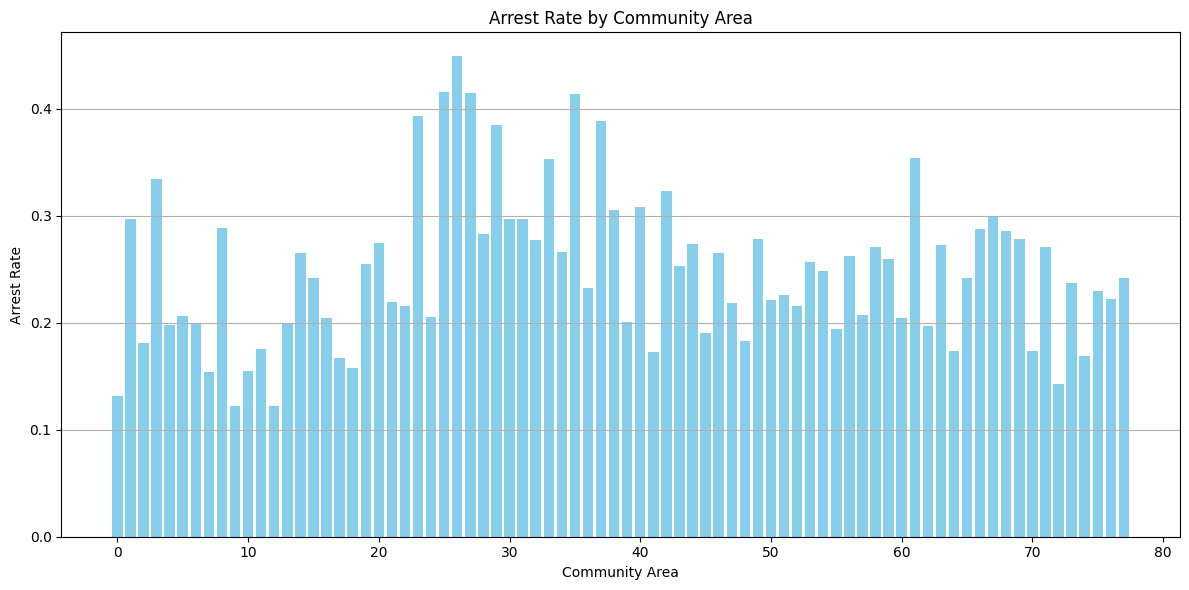

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.bar(arrest_by_area['Community Area'], arrest_by_area['Arrest Rate'], color='skyblue')
plt.xlabel('Community Area')
plt.ylabel('Arrest Rate')
plt.title('Arrest Rate by Community Area')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()


가설 :

귀무가설(H₀): 모든 Community Area의 체포율은 같다

대립가설(H₁): Community Area에 따라 체포율이 다르다

< 카이제곱검정>

In [ ]:
contingency_table = pd.crosstab(df_final['Community Area'], df_final['Arrest'])
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"📊 p-value: {p:.6f}")
if p < 0.05:
    print("✅ 지역별로 체포율에 유의미한 차이가 있습니다 (귀무가설 기각)")
else:
    print("❌ 지역별 체포율은 통계적으로 차이가 없습니다 (귀무가설 채택)")

📊 p-value: 0.000000
✅ 지역별로 체포율에 유의미한 차이가 있습니다 (귀무가설 기각)


### community area별 범죄 건수

<ipython-input-27-b0ace7ed349b>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=area_counts.index.astype(int), y=area_counts.values, palette="Blues_d")


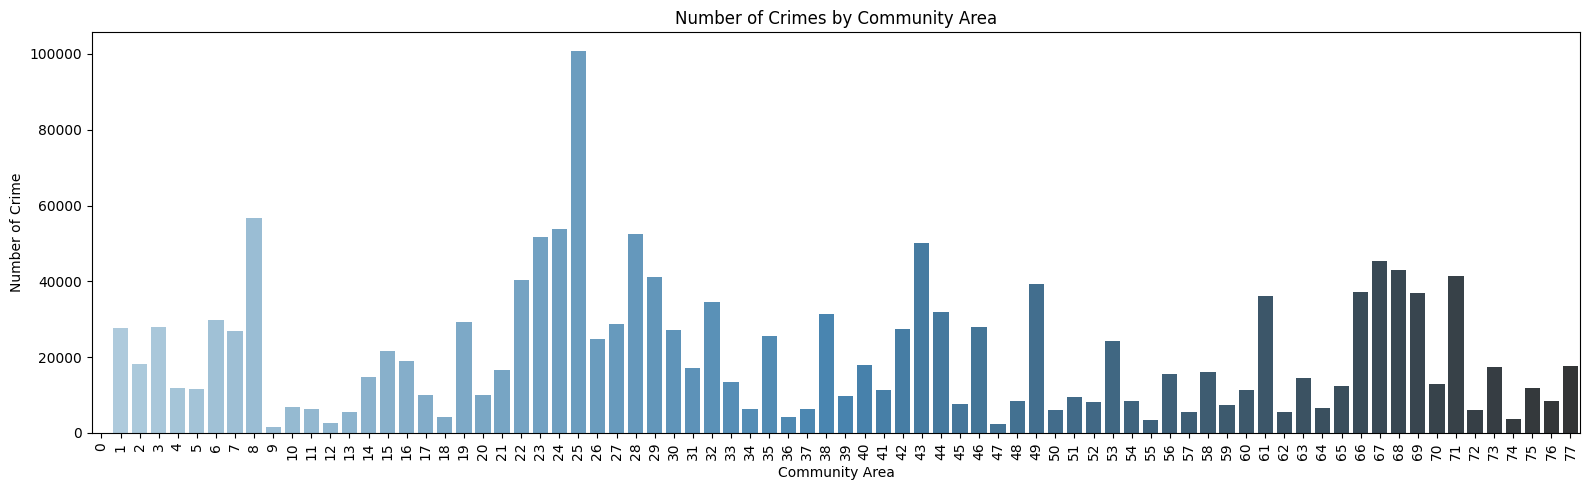

In [ ]:
import seaborn as sns
area_counts = df['Community Area'].value_counts().sort_index()

plt.figure(figsize=(16, 5))
sns.barplot(x=area_counts.index.astype(int), y=area_counts.values, palette="Blues_d")
plt.title("Number of Crimes by Community Area")
plt.xlabel("Community Area")
plt.ylabel("Number of Crime")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

📌 community ares 25가 가장 범죄가 많이 일어남

### community area 25

In [ ]:
# 25번 지역의 데이터만 필터링
area25 = df[df['Community Area'] == 25]

# 전체 사건 수
print(f"📌 Community Area 25 사건 수: {len(area25)}")

📌 Community Area 25 사건 수: 100652


#### 범죄 유형 top 10

📊 25번 지역에서 가장 많이 발생한 범죄 유형:
Primary Type
NARCOTICS              26190
BATTERY                20318
THEFT                  11794
CRIMINAL DAMAGE         8857
OTHER OFFENSE           6187
ASSAULT                 5930
MOTOR VEHICLE THEFT     4420
ROBBERY                 3905
BURGLARY                3450
PROSTITUTION            2230
Name: count, dtype: int64


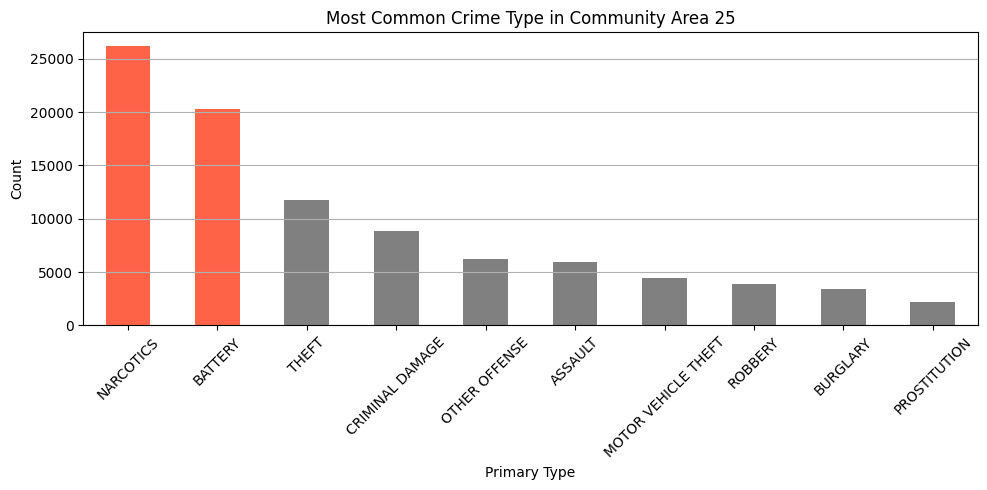

In [ ]:
# 범죄 유형 Top 10
top_crimes = area25['Primary Type'].value_counts().head(10)
print("📊 25번 지역에서 가장 많이 발생한 범죄 유형:")
print(top_crimes)

# 시각화
import matplotlib.pyplot as plt

colors = []
for crime in top_crimes.index:
    if crime == 'NARCOTICS':
        colors.append('tomato')
    elif crime == 'BATTERY':
        colors.append('tomato')
    else:
        colors.append('gray')

# 그래프 그리기
plt.figure(figsize=(10, 5))
top_crimes.plot(kind='bar', color=colors)
plt.title("Most Common Crime Type in Community Area 25")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

📌 마약, 폭행 범죄가 유독 높음

#### 시간대별 범죄 발생 건수

<ipython-input-29-99720cb687ef>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  area25['Date'] = pd.to_datetime(area25['Date'], errors='coerce')
<ipython-input-29-99720cb687ef>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  area25['Hour'] = area25['Date'].dt.hour


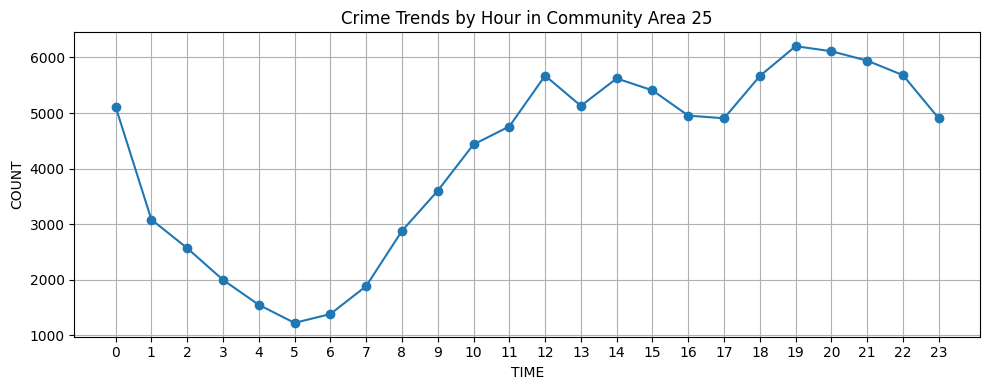

In [ ]:
# 시간 추출
area25['Date'] = pd.to_datetime(area25['Date'], errors='coerce')
area25['Hour'] = area25['Date'].dt.hour

# 시간대별 범죄 발생 건수
hourly = area25['Hour'].value_counts().sort_index()

plt.figure(figsize=(10, 4))
hourly.plot(kind='line', marker='o')
plt.title("Crime Trends by Hour in Community Area 25")
plt.xlabel("TIME")
plt.ylabel("COUNT")
plt.grid(True)
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()


📌 오후 시간에 많이 발생
: 오후 시간대는 사람도 많고, 활동도 많다
즉, 범죄가 발생하기 쉬운 환경적 조건이 집중되는 시간

#### 장소별 범죄 건수 top 10

📍 Top 10 Most Frequent Crime Locations in Community Area 25:
Location Description
STREET                            34236
RESIDENCE                         18184
SIDEWALK                          15677
APARTMENT                          7771
ALLEY                              3722
OTHER                              3047
RESIDENCE PORCH/HALLWAY            2023
SCHOOL, PUBLIC, BUILDING           2001
PARKING LOT/GARAGE(NON.RESID.)     1822
RESIDENCE-GARAGE                   1311
Name: count, dtype: int64


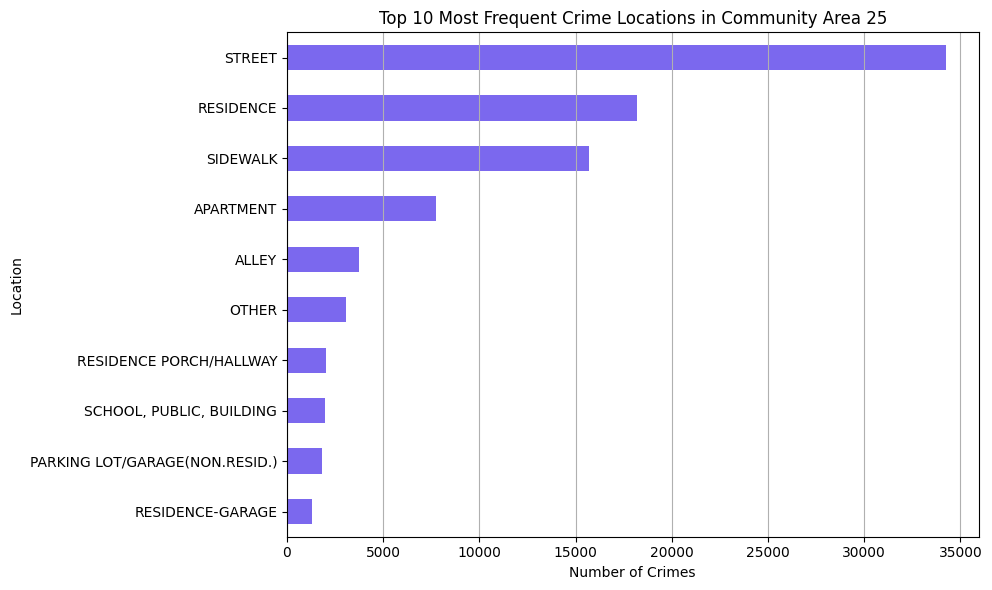

In [ ]:
top_places = area25['Location Description'].value_counts().head(10)
print("📍 Top 10 Most Frequent Crime Locations in Community Area 25:")
print(top_places)

import pandas as pd
import matplotlib.pyplot as plt

# 25번 지역 데이터 필터링
area25 = df[df['Community Area'] == 25]

# 장소별 범죄 건수 Top 10
top_locations = area25['Location Description'].value_counts().head(10)

# 시각화
plt.figure(figsize=(10, 6))
top_locations.plot(kind='barh', color='mediumslateblue')
plt.title("Top 10 Most Frequent Crime Locations in Community Area 25")
plt.xlabel("Number of Crimes")
plt.ylabel("Location")
plt.gca().invert_yaxis()
plt.grid(True, axis='x')
plt.tight_layout()
plt.show()


📍 길거리, 일반 주택, 인도에서 가장 많이 일어남
📍 전체 데이터에서 범죄 건수 top 30의 location description과 유사

#### 25번 지역 체포율

In [ ]:
arrest_rate = area25['Arrest'].mean()
print(f"✅ 25번 지역 체포율: {arrest_rate:.2%}")


✅ 25번 지역 체포율: 41.99%


community area 25 : Austin

- 시카고 서부, 인구밀집, 빈곤율 높음, 역사적으로 높은 범죄율 (외부데이터 필요)
- 높은 실업률 교육 격차, 공공주택 밀집, 경찰 자원 부족

#### community area 서부

In [ ]:
west_community_areas = [23, 24, 25, 26, 27, 28]  # Austin, West Garfield Park 등


import pandas as pd

# 마약 범죄 필터링
narcotics_df = df_final[df_final['Primary Type'] == 'NARCOTICS']

# 서쪽 커뮤니티 지역 필터링
west_community_areas = [23, 24, 25, 26, 27, 28]  # West Side 예시
west_narcotics_df = narcotics_df[narcotics_df['Community Area'].isin(west_community_areas)]

# 비율 계산
total_narcotics = len(narcotics_df)
west_narcotics = len(west_narcotics_df)
percentage = (west_narcotics / total_narcotics) * 100

print(f"🚨 시카고 서쪽 마약 범죄 건수: {west_narcotics:,}")
print(f"🌆 전체 마약 범죄 건수: {total_narcotics:,}")
print(f"📊 서쪽 마약 범죄 비율: {percentage:.2f}%")


🚨 시카고 서쪽 마약 범죄 건수: 227,736
🌆 전체 마약 범죄 건수: 674,503
📊 서쪽 마약 범죄 비율: 33.76%


## Location Description

In [ ]:
# 전체 사건 수
total_count = df_final.shape[0]

# 상위 20개 장소 추출
top20_locations = df_final['Location Description'].value_counts().head(20)

# 상위 10개 장소의 사건 수 합계
top20_total = top20_locations.sum()

# 비율 계산
top20_ratio = top20_total / total_count * 100

# 출력
print(f"📍 전체 사건 중 상위 20개 장소의 비율: {top20_ratio:.2f}%")


📍 전체 사건 중 상위 20개 장소의 비율: 90.10%


가설 : location description 별로 체포율이 다를 것이다.

In [ ]:
# 공백 제거 등 전처리 (선택)
import pandas as pd
df_final.columns = df_final.columns.str.strip()

# 고유 장소 수 계산
unique_count = df_final["Location Description"].nunique()
unique_count_with_nan = df_final["Location Description"].nunique(dropna=False)

# 출력
print(f"🔢 고유 장소 수 (결측치 제외): {unique_count}")

# Location Description 상위 20개 항목
top20_locations = df_final["Location Description"].value_counts().head(20).index

🔢 고유 장소 수 (결측치 제외): 173


### TOP 20 과 arrest 상관관계 - ANOVA TEST

📊 ANOVA F-Statistic: 29752.1493
🧪 P-Value: 0
✅ 장소에 따라 체포 여부가 유의미하게 존재합니다.


                        Multiple Comparison of Means - Tukey HSD, FWER=0.05                         
            group1                         group2             meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------------------------------------
                         ALLEY                      APARTMENT  -0.2944    0.0 -0.2988 -0.2899   True
                         ALLEY        CHA PARKING LOT/GROUNDS   0.2327    0.0   0.225  0.2404   True
                         ALLEY   COMMERCIAL / BUSINESS OFFICE  -0.3794    0.0 -0.3876 -0.3712   True
                         ALLEY               DEPARTMENT STORE   0.1223    0.0  0.1155  0.1292   True
                         ALLEY                    GAS STATION  -0.0839    0.0 -0.0911 -0.0767   True
                         ALLEY             GROCERY FOOD STORE   0.0827    0.0   0.076  0.0894   True
                         ALLEY                          OTHER  -0.2755    0.0 -0.2806 -0.27

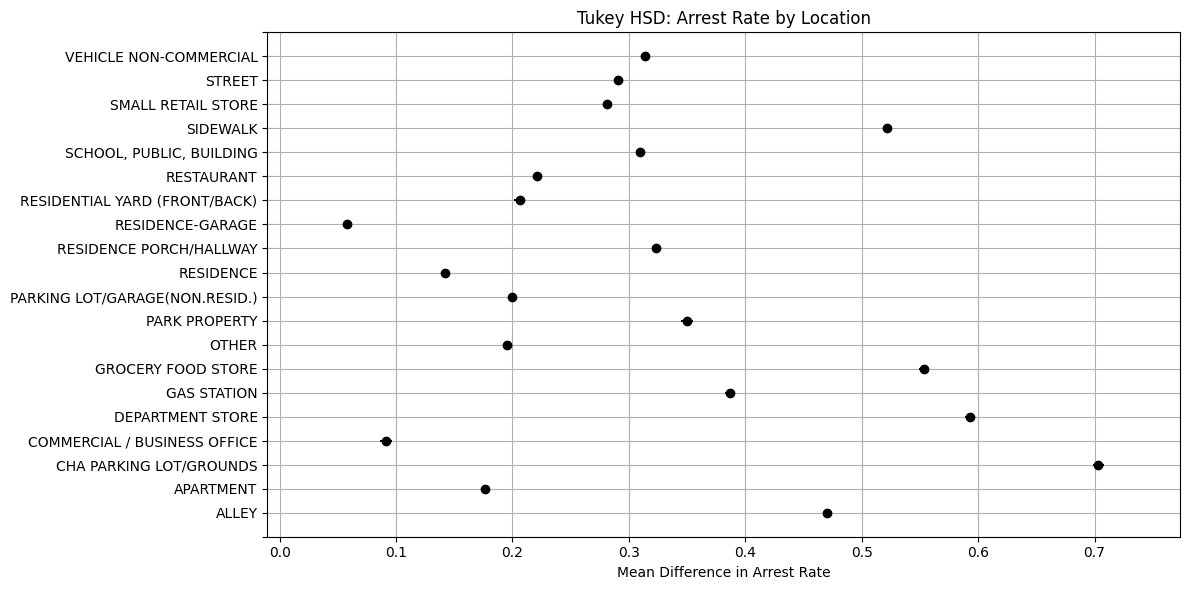

In [ ]:
from scipy.stats import f_oneway

# 상위 20개 장소만 분석
sample20 = [df_final[df_final['Location Description'] == loc]['Arrest'].astype(int) for loc in top20_locations]

f_stat, p_val = f_oneway(*sample20)
print(f"📊 ANOVA F-Statistic: {f_stat:.4f}")
print(f"🧪 P-Value: {p_val:.4g}")

if p_val < 0.05:
    print("✅ 장소에 따라 체포 여부가 유의미하게 존재합니다.")
else:
    print("❌ 장소에 따른 체포 여부는 통계적으로 유의미하지 않습니다.")

from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 🔍 상위 10개 장소 필터링
filtered = df_final[df_final['Location Description'].isin(top20_locations)].copy()
filtered['Arrest'] = filtered['Arrest'].astype(int)

# ✅ Tukey HSD 사후 검정
tukey = pairwise_tukeyhsd(
    endog=filtered['Arrest'],
    groups=filtered['Location Description'],
    alpha=0.05
)

# 결과 출력
print(tukey)

# 📊 시각화 (선택)
import matplotlib.pyplot as plt
tukey.plot_simultaneous(figsize=(12,6))
plt.title("Tukey HSD: Arrest Rate by Location")
plt.xlabel("Mean Difference in Arrest Rate")
plt.grid(True)
plt.tight_layout()
plt.show()



In [ ]:
# Tukey 결과를 표로 변환
import pandas as pd

tukey_df = pd.DataFrame(
    tukey._results_table.data[1:],
    columns=tukey._results_table.data[0]
)

# 예시: COMMERCIAL / BUSINESS OFFICE가 포함된 쌍만 보고 싶을 때
subset = tukey_df[
    (tukey_df['group1'] == 'COMMERCIAL / BUSINESS OFFICE') |
    (tukey_df['group2'] == 'COMMERCIAL / BUSINESS OFFICE')
]

# 결과 출력
print(subset)



                          group1                          group2  meandiff  \
2                          ALLEY    COMMERCIAL / BUSINESS OFFICE   -0.3794   
20                     APARTMENT    COMMERCIAL / BUSINESS OFFICE   -0.0850   
37       CHA PARKING LOT/GROUNDS    COMMERCIAL / BUSINESS OFFICE   -0.6121   
54  COMMERCIAL / BUSINESS OFFICE                DEPARTMENT STORE    0.5017   
55  COMMERCIAL / BUSINESS OFFICE                     GAS STATION    0.2955   
56  COMMERCIAL / BUSINESS OFFICE              GROCERY FOOD STORE    0.4621   
57  COMMERCIAL / BUSINESS OFFICE                           OTHER    0.1039   
58  COMMERCIAL / BUSINESS OFFICE                   PARK PROPERTY    0.2587   
59  COMMERCIAL / BUSINESS OFFICE  PARKING LOT/GARAGE(NON.RESID.)    0.1083   
60  COMMERCIAL / BUSINESS OFFICE                       RESIDENCE    0.0510   
61  COMMERCIAL / BUSINESS OFFICE         RESIDENCE PORCH/HALLWAY    0.2325   
62  COMMERCIAL / BUSINESS OFFICE                RESIDENCE-GARAGE

###location description별 체포율

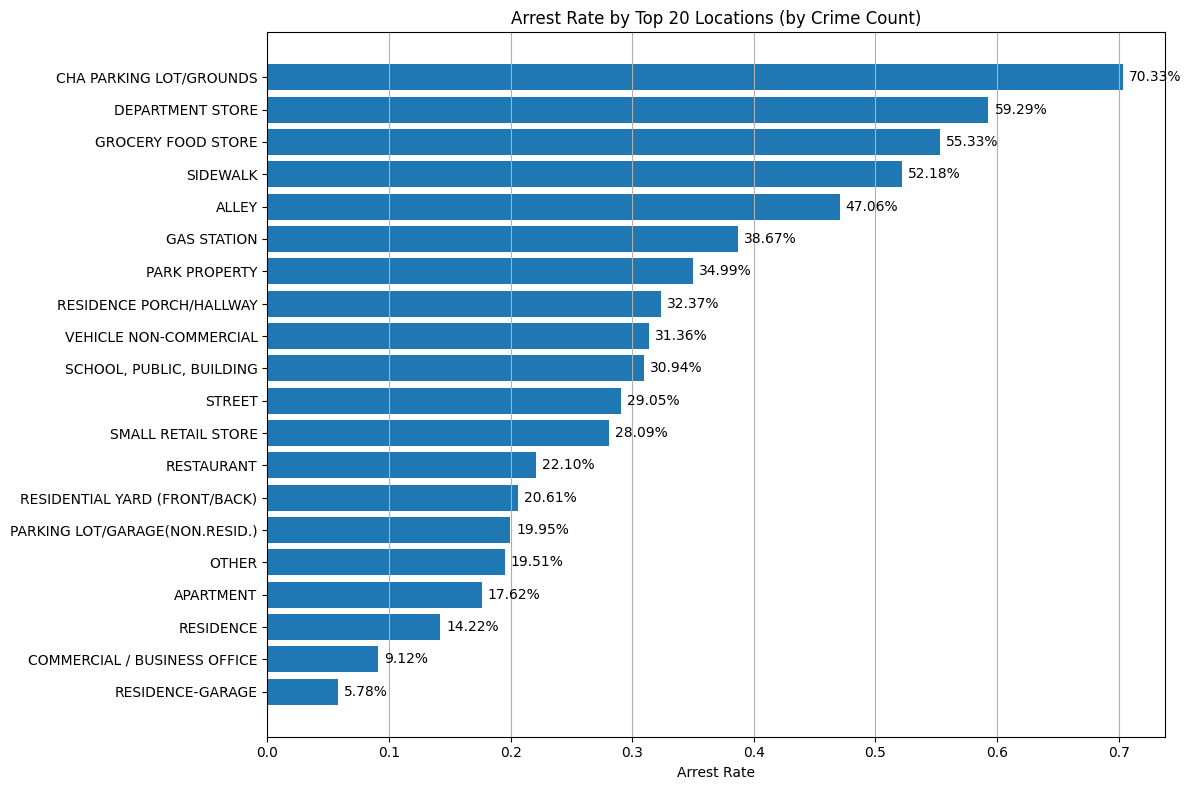

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# top20 장소에 해당하는 데이터만 필터링
top20_data = df_final[df_final["Location Description"].isin(top20_locations)]

# 장소별 사건 수와 체포 수 집계
top20_stats = top20_data.groupby("Location Description").agg(
    total_cases=('Arrest', 'count'),
    arrests=('Arrest', 'sum')
).reset_index()

# 체포율 계산
top20_stats["arrest_rate"] = top20_stats["arrests"] / top20_stats["total_cases"]

# 체포율 기준 정렬
top20_stats_sorted = top20_stats.sort_values("arrest_rate", ascending=False)

# 시각화
plt.figure(figsize=(12, 8))
bars = plt.barh(top20_stats_sorted["Location Description"], top20_stats_sorted["arrest_rate"])
plt.xlabel("Arrest Rate")
plt.title("Arrest Rate by Top 20 Locations (by Crime Count)")
plt.gca().invert_yaxis()
plt.grid(True, axis='x')

# 막대 옆에 체포율 수치 표시
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.005, bar.get_y() + bar.get_height()/2,
             f"{width:.2%}", va='center')

plt.tight_layout()
plt.show()


<체포율이 50%가 넘는 장소>
- CHA HALLWAY/STAIRWELL/ELEVATOR (시카고 공공주택 복도/계단/엘리베이터)
- CHA PARKING LOT/GROUNDS (시카고 공공주택 주차장/야외궁간)
- TA PLATFORM (시카고 지하철 승강장)
- DEPARTMENT STORE (백화점)
- DRUG STORE (약국)


1. 감시가 용이한 공간

  📷 CCTV 설치 가능성 높음

  👮‍♀️ 직원, 보안 요원이 상주하는 공간 → 즉각 대응 가능


2. 공공기관 또는 준공공공간

  👮경찰 순찰이 자주 이뤄짐

  🚇시카고교통청 운영, 보안 강화 구역


3. 폐쇄적이고 공간이 제한된 구조

 🛗 엘리베이터, 계단, 복도 → 도망치기 어려움

  ❌제한된 입출입 → 현장 검거 가능성↑


<체포율이 낮은 장소>

- RESIDENCE-GARAGE (주택 내 차고)

- COMMERCIAL/BUSINESS OFFICE (상업/업무용 사무실)

- BANK, APARTMENT, RESIDENCE (은행/아파트/일반 주택 거주지)

1. 비공개 공간 (수사·체포 접근 어려움)

2. 사후 수사 위주 (범죄 후 시간이 지나 발견)

3. 신고자 or 목격자 부재


In [ ]:
print("📍 상위 20개 장소별 범죄 건수:")
print(top20_locations)


📍 상위 20개 장소별 범죄 건수:
Index(['STREET', 'RESIDENCE', 'APARTMENT', 'SIDEWALK', 'OTHER',
       'PARKING LOT/GARAGE(NON.RESID.)', 'ALLEY', 'SCHOOL, PUBLIC, BUILDING',
       'RESIDENCE-GARAGE', 'RESIDENCE PORCH/HALLWAY', 'SMALL RETAIL STORE',
       'VEHICLE NON-COMMERCIAL', 'RESTAURANT', 'GROCERY FOOD STORE',
       'DEPARTMENT STORE', 'GAS STATION', 'RESIDENTIAL YARD (FRONT/BACK)',
       'CHA PARKING LOT/GROUNDS', 'PARK PROPERTY',
       'COMMERCIAL / BUSINESS OFFICE'],
      dtype='object', name='Location Description')


📍 상위 20개 장소별 범죄 건수:

STREET  :  거리                           

RESIDENCE  :  주거지                  

SIDEWALK  :  인도                         

APARTMENT  :  아파트                       

OTHER  :  기타                            

PARKING LOT/GARAGE(NON.RESID.)  : 주차장/차고 (비주거용)

ALLEY  :  골목

SCHOOL, PUBLIC, BUILDING  :  공립학교 건물

RESIDENCE-GARAGE  :  주거지 차고

RESIDENCE PORCH/HALLWAY  :  주거지 현관/복도

SMALL RETAIL STORE  :  소형 소매점

VEHICLE NON-COMMERCIAL  :  	비영업용 차량

RESTAURANT  :  식당

GROCERY FOOD STORE  :  	식료품점

DEPARTMENT STORE  :  백화점

GAS STATION  :  주유소

RESIDENTIAL YARD (FRONT/BACK)  :  주거지 마당 (앞/뒤)

CHA PARKING LOT/GROUNDS  :  시카고 공공주택청(CHA) 주차장/부지

PARK PROPERTY  :  	공원 부지

COMMERCIAL / BUSINESS OFFICE  :  상업/업무용 사무실


### location description별 범죄 건수

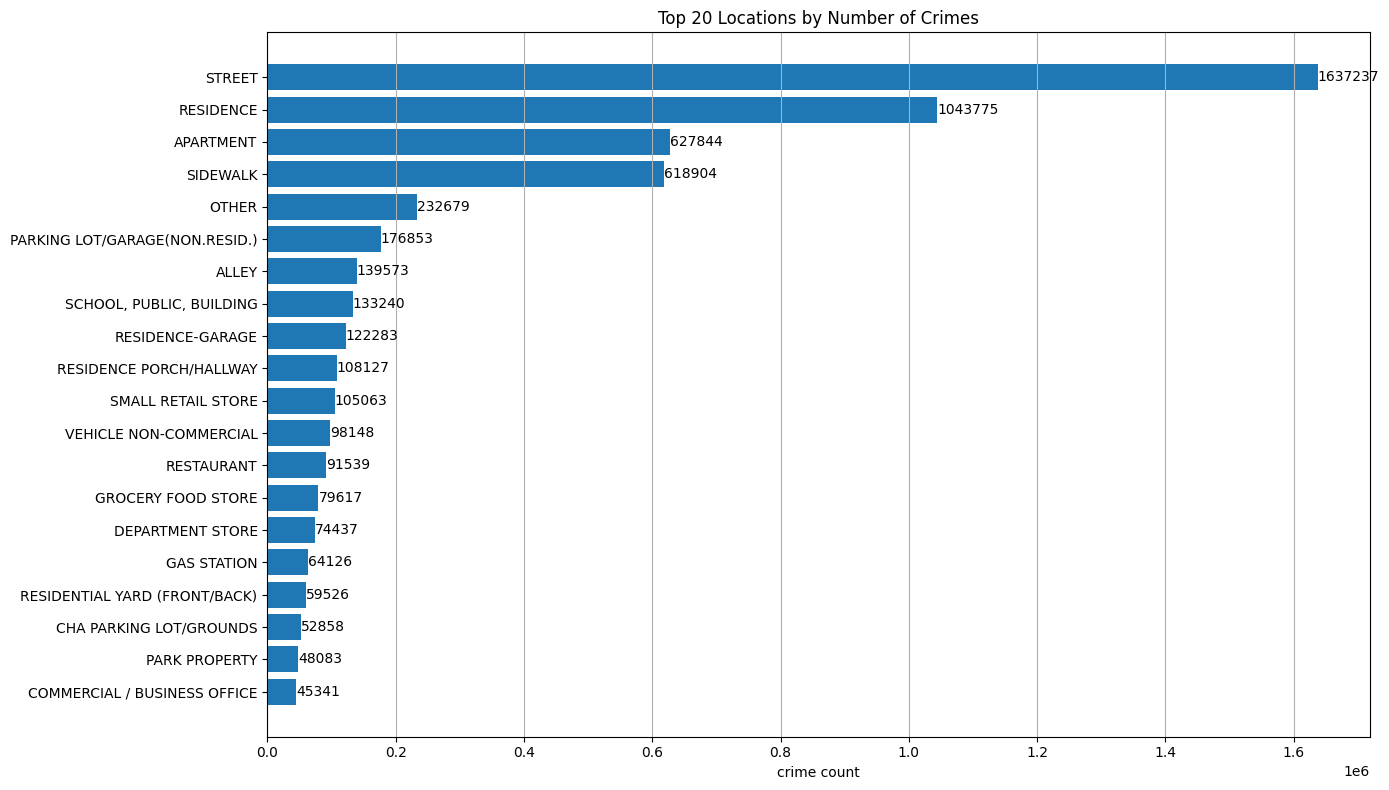

In [ ]:
import matplotlib.pyplot as plt

# 상위 20개 장소와 그에 해당하는 범죄 건수 가져오기
top20_counts = df_final["Location Description"].value_counts().head(20)

# 시각화
plt.figure(figsize=(14, 8))
bars = plt.barh(top20_counts.index, top20_counts.values)
plt.xlabel("crime count")
plt.title("Top 20 Locations by Number of Crimes")
plt.gca().invert_yaxis()
plt.grid(True, axis='x')

# 범죄 건수 수치 표시
for bar in bars:
    width = bar.get_width()
    plt.text(width + 10, bar.get_y() + bar.get_height() / 2,
             f"{int(width)}", va="center")

plt.tight_layout()
plt.show()


### location description별 범죄 유형 분석

In [ ]:
# 장소 이름만 리스트로 추출
top20_locations = df_final["Location Description"].value_counts().head(20).index.tolist()

filtered_data = df_final[df_final["Location Description"].isin(top20_locations)]

result = []

# 각 장소마다 상위 3개 범죄 유형 구하기
for location in top20_locations:
    subset = filtered_data[filtered_data["Location Description"] == location]
    top_crimes = subset["Primary Type"].value_counts().head(3)

    # 값이 3개보다 적을 수도 있으므로 예외 처리
    crimes = top_crimes.index.tolist()
    counts = top_crimes.values.tolist()
    while len(crimes) < 3:
        crimes.append(None)
        counts.append(None)

    result.append({
        "Location Description": location,
        "1st Most Common": crimes[0],
        "Count 1": counts[0],
        "2nd Most Common": crimes[1],
        "Count 2": counts[1],
        "3rd Most Common": crimes[2],
        "Count 3": counts[2]
    })

# DataFrame으로 변환
summary_df.index = summary_df.index + 1  # 인덱스를 1부터 시작하도록 수정

# 출력
from IPython.display import display
display(summary_df)



,Location Description,1st Most Common,Count 1,2nd Most Common,Count 2,3rd Most Common,Count 3
1,STREET,THEFT,355850,CRIMINAL DAMAGE,257081,NARCOTICS,240629
2,RESIDENCE,BATTERY,235558,OTHER OFFENSE,178220,THEFT,137789
3,APARTMENT,BATTERY,218979,BURGLARY,103196,CRIMINAL DAMAGE,71511
4,SIDEWALK,NARCOTICS,212935,BATTERY,168205,ROBBERY,72274
5,OTHER,THEFT,74370,CRIMINAL DAMAGE,26854,BATTERY,24692
6,PARKING LOT/GARAGE(NON.RESID.),THEFT,65912,CRIMINAL DAMAGE,30084,MOTOR VEHICLE THEFT,22954
7,ALLEY,NARCOTICS,42886,BATTERY,25011,ROBBERY,16342
8,"SCHOOL, PUBLIC, BUILDING",BATTERY,46507,THEFT,23948,ASSAULT,22967
9,RESIDENCE-GARAGE,BURGLARY,63387,CRIMINAL DAMAGE,33150,THEFT,14186
10,RESIDENCE PORCH/HALLWAY,BATTERY,28364,THEFT,19136,ASSAULT,15954


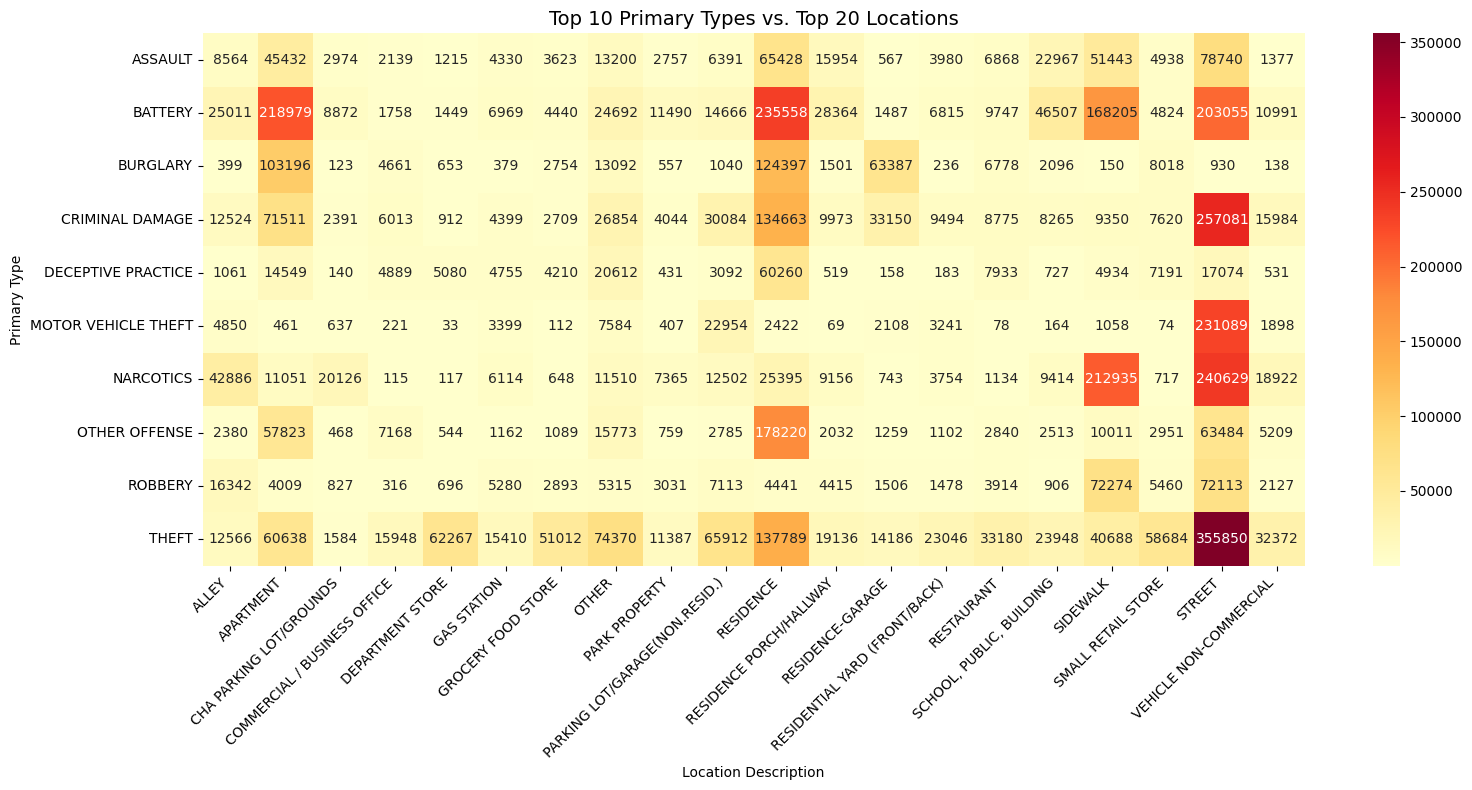

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ✅ 상위 10개 범죄유형과 20개 장소 추출
top_10_crimes = df_final['Primary Type'].value_counts().head(10).index
top_20_locations = df_final['Location Description'].value_counts().head(20).index

# ✅ 조건에 맞는 데이터 필터링
filtered_df = df_final[
    df_final['Primary Type'].isin(top_10_crimes) &
    df_final['Location Description'].isin(top_20_locations)
]

# ✅ 범죄유형 vs 장소 교차표 생성
pivot_table = pd.crosstab(filtered_df['Primary Type'], filtered_df['Location Description'])

# ✅ 히트맵 시각화
plt.figure(figsize=(16, 8))
sns.heatmap(pivot_table, annot=True, fmt='d', cmap='YlOrRd')
plt.title("Top 10 Primary Types vs. Top 20 Locations", fontsize=14)
plt.xlabel("Location Description")
plt.ylabel("Primary Type")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## Primary Type

가설 : 시카고에서 가장 많이 일어나는 범죄는 무엇일까?

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 범죄 유형별 건수 계산
top_crimes = df["Primary Type"].value_counts().head(10)
print(top_crimes)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_crimes.values, y=top_crimes.index, palette="Oranges")

plt.title("상위 10개 범죄 유형")
plt.xlabel("건 수")
plt.ylabel("범죄 유형")
plt.tight_layout()
plt.show()

1. 절도
2. 폭행
3. 가물 손괴
4. 마약 범죄
5. 기타 범죄
6. 폭언/협박
7. 주거침입
8. 차량 절도
9. 강도
10. 불법 침입

가설 : 범죄 발생 건수는 연도에 따라 유의미하게 증가하고 있다.

In [ ]:
from scipy.stats import linregress

# 연도별 총 건수
year_counts = df_final['Year'].value_counts().sort_index()

# 선형 회귀 (X: Year, Y: Count)
slope, intercept, r_value, p_value, std_err = linregress(year_counts.index, year_counts.values)

print(f"📈 기울기: {slope:.2f}")
print(f"📊 p-value: {p_value:.6f}")
if p_value < 0.05:
    print("✅ 시간에 따라 범죄가 통계적으로 유의미하게 증가/감소하고 있음")
else:
    print("❌ 연도별 증감은 우연일 수 있음")


📈 기울기: 234.55
📊 p-value: 0.068014
❌ 연도별 증감은 우연일 수 있음


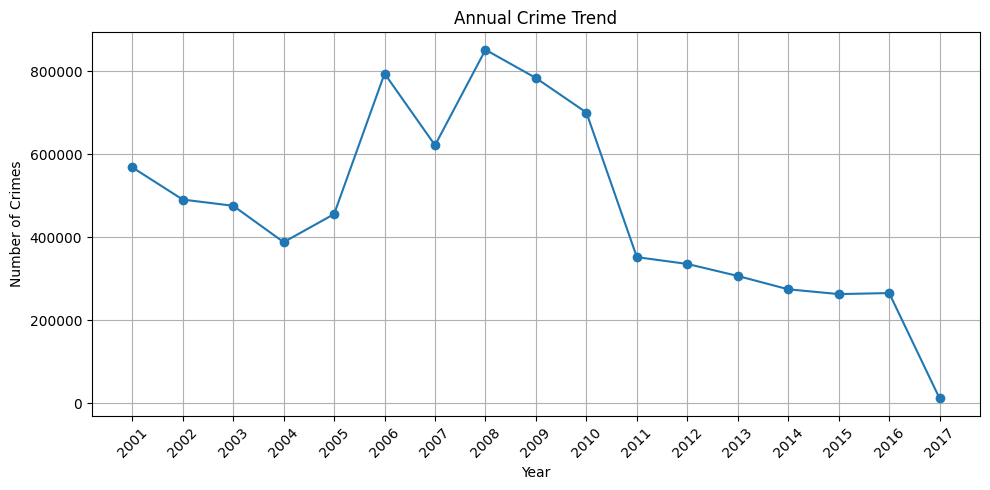

In [ ]:
# 1. 연도 정수형으로 변환
df_final['Year'] = pd.to_numeric(df_final['Year'], errors='coerce')

# 2. 정상 연도만 필터링 (예: 2001 ~ 2023)
df_year_filtered = df_final[(df_final['Year'] >= 2001) & (df_final['Year'] <= 2023)]

# 3. 연도별 건수 세기
year_counts = df_year_filtered['Year'].value_counts().sort_index()

# 4. 시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(year_counts.index, year_counts.values, marker='o')
plt.title("Annual Crime Trend")
plt.xlabel("Year")
plt.ylabel("Number of Crimes")
plt.grid(True)
plt.xticks(year_counts.index, rotation=45)
plt.tight_layout()
plt.show()

#### 범죄 유형과 체포율

가설 : 범죄 유형에 따라 체포율(Arrest 비율)에 차이가 있을 것이다.

< 카이제곱검정 >

In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency

# 교차표 생성
contingency = pd.crosstab(df_final['Primary Type'], df_final['Arrest'])

# 카이제곱 검정
chi2, p, dof, expected = chi2_contingency(contingency)

# 결과 출력
print("📌 카이제곱 독립성 검정 결과")
print(f"🔹 Chi-squared statistic: {chi2:.4f}")
print(f"🔹 Degrees of freedom: {dof}")
print(f"🔹 p-value: {p:.6f}")

# 기대 빈도표 보기 (옵션)
expected_df = pd.DataFrame(expected, index=contingency.index, columns=contingency.columns)
print("\n🔍 기대 빈도표 (Expected Frequencies):")
print(expected_df.round(1))

# 해석
if p < 0.05:
    print("\n✅ 범죄 유형에 따라 체포율 차이가 있습니다 (귀무가설 기각)")
else:
    print("\n❌ 체포율은 범죄 유형과 통계적으로 관련이 없습니다 (귀무가설 채택)")



📌 카이제곱 독립성 검정 결과
🔹 Chi-squared statistic: 2797680.3266
🔹 Degrees of freedom: 34
🔹 p-value: 0.000000

🔍 기대 빈도표 (Expected Frequencies):
Arrest                                False     True 
Primary Type                                         
ARSON                                7373.7    2905.3
ASSAULT                            270362.7  106525.3
BATTERY                            807545.1  318179.9
BURGLARY                           259413.0  102211.0
CONCEALED CARRY LICENSE VIOLATION      64.6      25.4
CRIM SEXUAL ASSAULT                 16934.6    6672.4
CRIMINAL DAMAGE                    509382.0  200701.0
CRIMINAL TRESPASS                  127690.7   50311.3
DECEPTIVE PRACTICE                 160146.0   63099.0
DOMESTIC VIOLENCE                       0.7       0.3
GAMBLING                             9959.8    3924.2
HOMICIDE                             5923.2    2333.8
HUMAN TRAFFICKING                      20.1       7.9
INTERFERENCE WITH PUBLIC OFFICER     9231.6    3637.4
IN

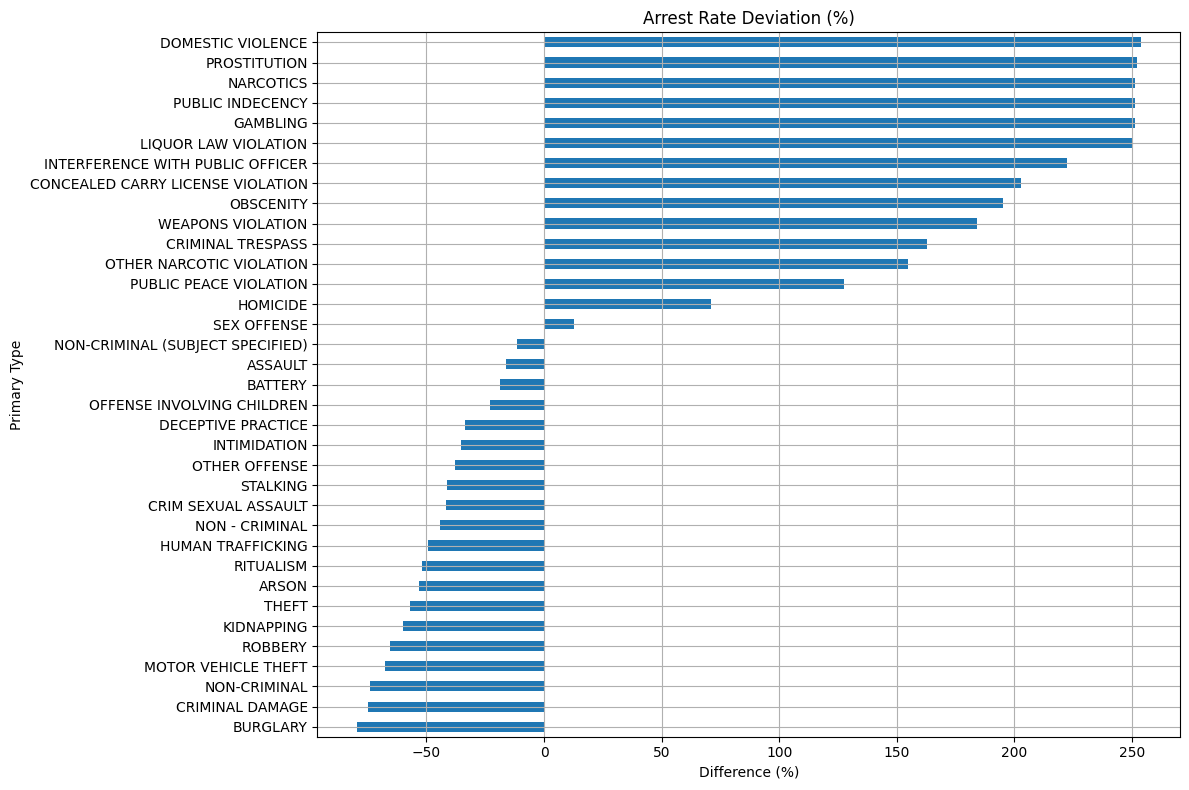

In [ ]:
observed = pd.crosstab(df_final['Primary Type'], df_final['Arrest'])
expected_df = pd.DataFrame(expected, index=observed.index, columns=observed.columns)

# 차이 계산
diff = observed - expected_df
diff_percent = ((diff / expected_df) * 100).round(2)

# 체포(True) 기준 정렬
diff_percent_sorted = diff_percent.sort_values(by=True)

diff_percent_sorted[True].plot(kind='barh', figsize=(12, 8), title='Arrest Rate Deviation (%)')
plt.xlabel("Difference (%)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
from scipy.stats import f_oneway

# 범죄 유형별로 Arrest (True=1, False=0)를 묶음
groups = [group['Arrest'].astype(int) for name, group in df_final.groupby('Primary Type')]
f_stat, p = f_oneway(*groups)

print(f"🔹 F-statistic: {f_stat:.4f}")
print(f"p-value: {p}")
if p < 0.05:
    print("✅ 범죄 유형에 따라 평균 체포율이 통계적으로 다릅니다 (귀무가설 기각)")
else:
    print("❌ 평균 체포율에 유의미한 차이는 없습니다 (귀무가설 채택)")


🔹 F-statistic: 150530.9044
p-value: 0.0
✅ 범죄 유형에 따라 평균 체포율이 통계적으로 다릅니다 (귀무가설 기각)


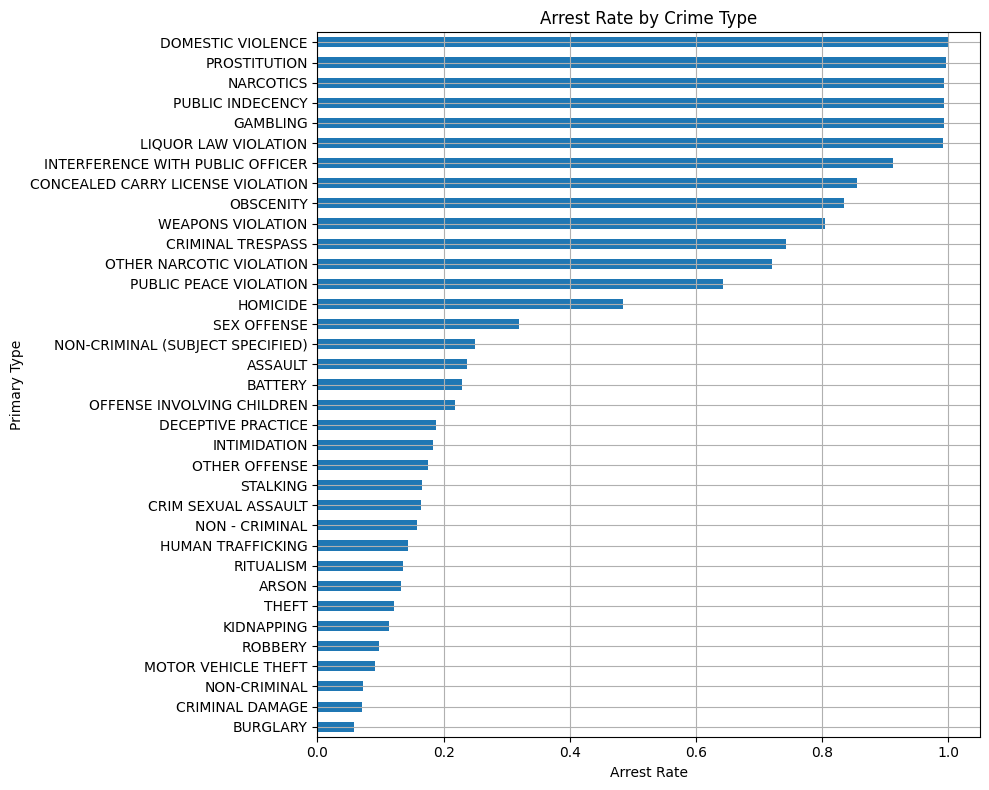

In [ ]:
import matplotlib.pyplot as plt

arrest_rate = df_final.groupby('Primary Type')['Arrest'].mean().sort_values()
plt.figure(figsize=(10, 8))
arrest_rate.plot(kind='barh')
plt.title('Arrest Rate by Crime Type')
plt.xlabel('Arrest Rate')
plt.tight_layout()
plt.grid(True)
plt.show()


#### 범죄 유형과 발생소

가설 : 범죄 유형과 발생 장소에 유의미한 관계가 있을 것이다

In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency

# 결측치 제거
filtered = df_final.dropna(subset=["Primary Type", "Location Description"])

# 교차표 생성
contingency = pd.crosstab(filtered["Primary Type"], filtered["Location Description"])

# 카이제곱 검정 수행
chi2, p, dof, expected = chi2_contingency(contingency)

# 결과 출력
print("📌 Chi-squared Test: Crime Type vs Location")
print(f"🔹 Chi-squared statistic: {chi2:.4f}")
print(f"🔹 Degrees of freedom: {dof}")
print(f"🔹 p-value: {p:.6f}")

# 해석
if p < 0.05:
    print("✅ 범죄 유형에 따라 발생 장소에 유의미한 차이가 있습니다 (귀무가설 기각)")
else:
    print("❌ 범죄 유형과 장소는 통계적으로 관련이 없습니다 (귀무가설 채택)")


📌 Chi-squared Test: Crime Type vs Location
🔹 Chi-squared statistic: 7605266.4326
🔹 Degrees of freedom: 5848
🔹 p-value: 0.000000
✅ 범죄 유형에 따라 발생 장소에 유의미한 차이가 있습니다 (귀무가설 기각)


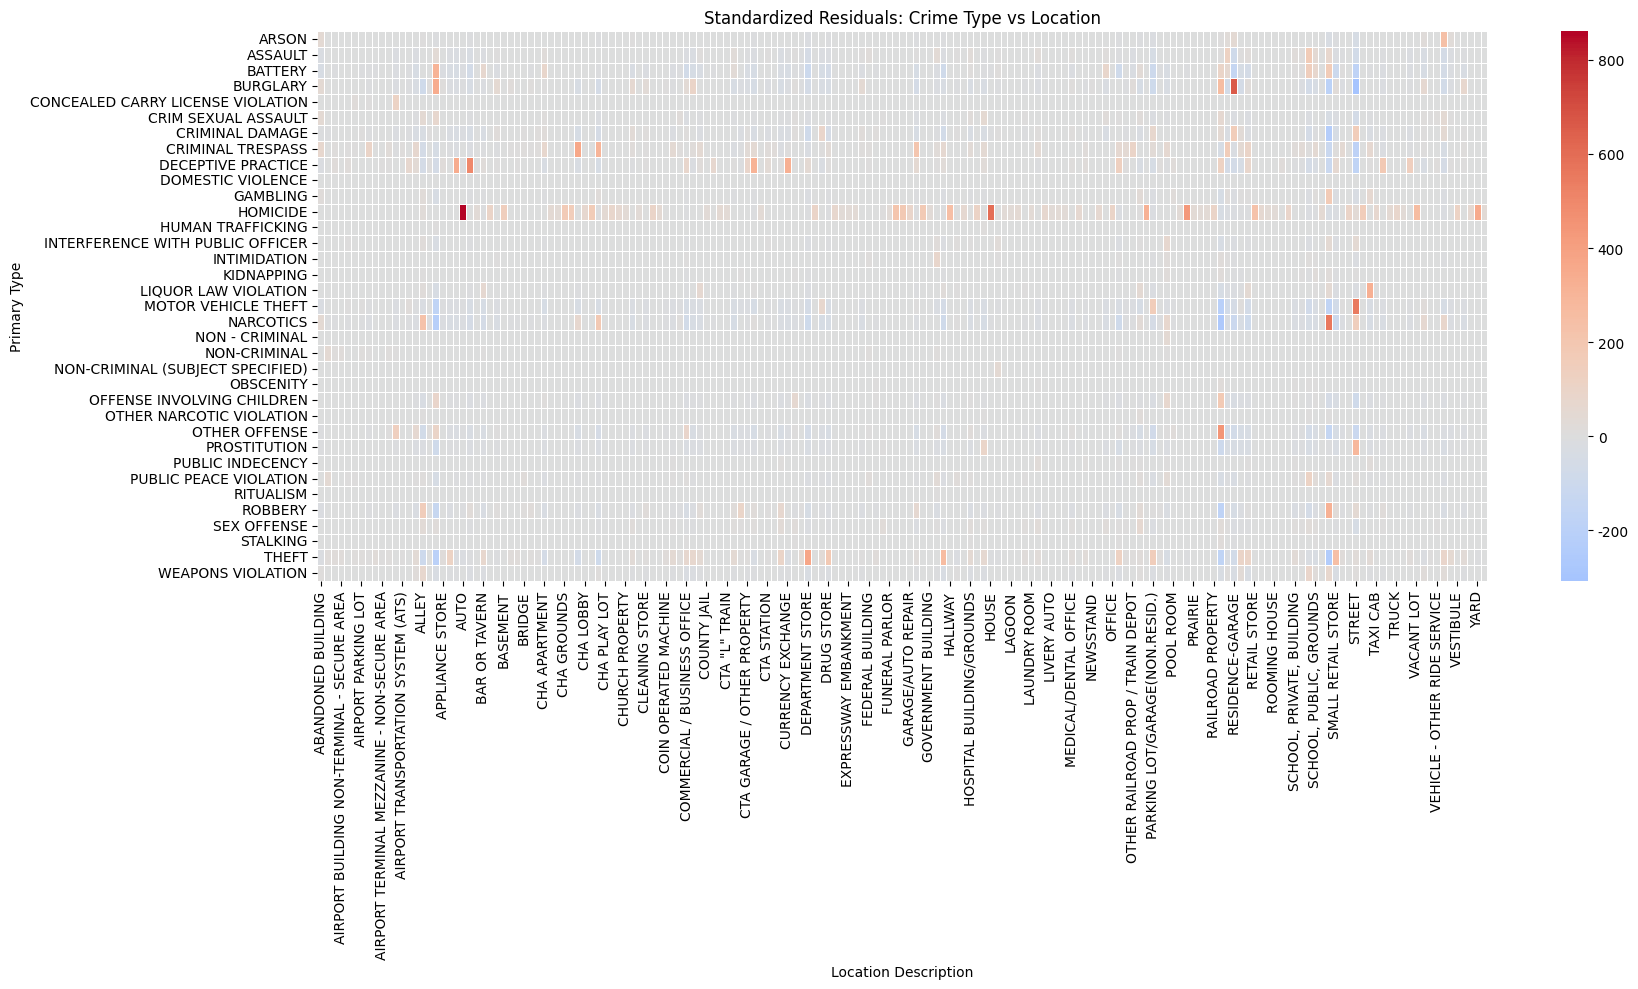

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 잔차 (표준화된 차이) 계산
residuals = (contingency - expected) / np.sqrt(expected)

# 2. 히트맵 시각화
plt.figure(figsize=(18, 10))
sns.heatmap(residuals, cmap="coolwarm", center=0, annot=False, linewidths=.5)
plt.title("Standardized Residuals: Crime Type vs Location")
plt.xlabel("Location Description")
plt.ylabel("Primary Type")
plt.tight_layout()
plt.show()


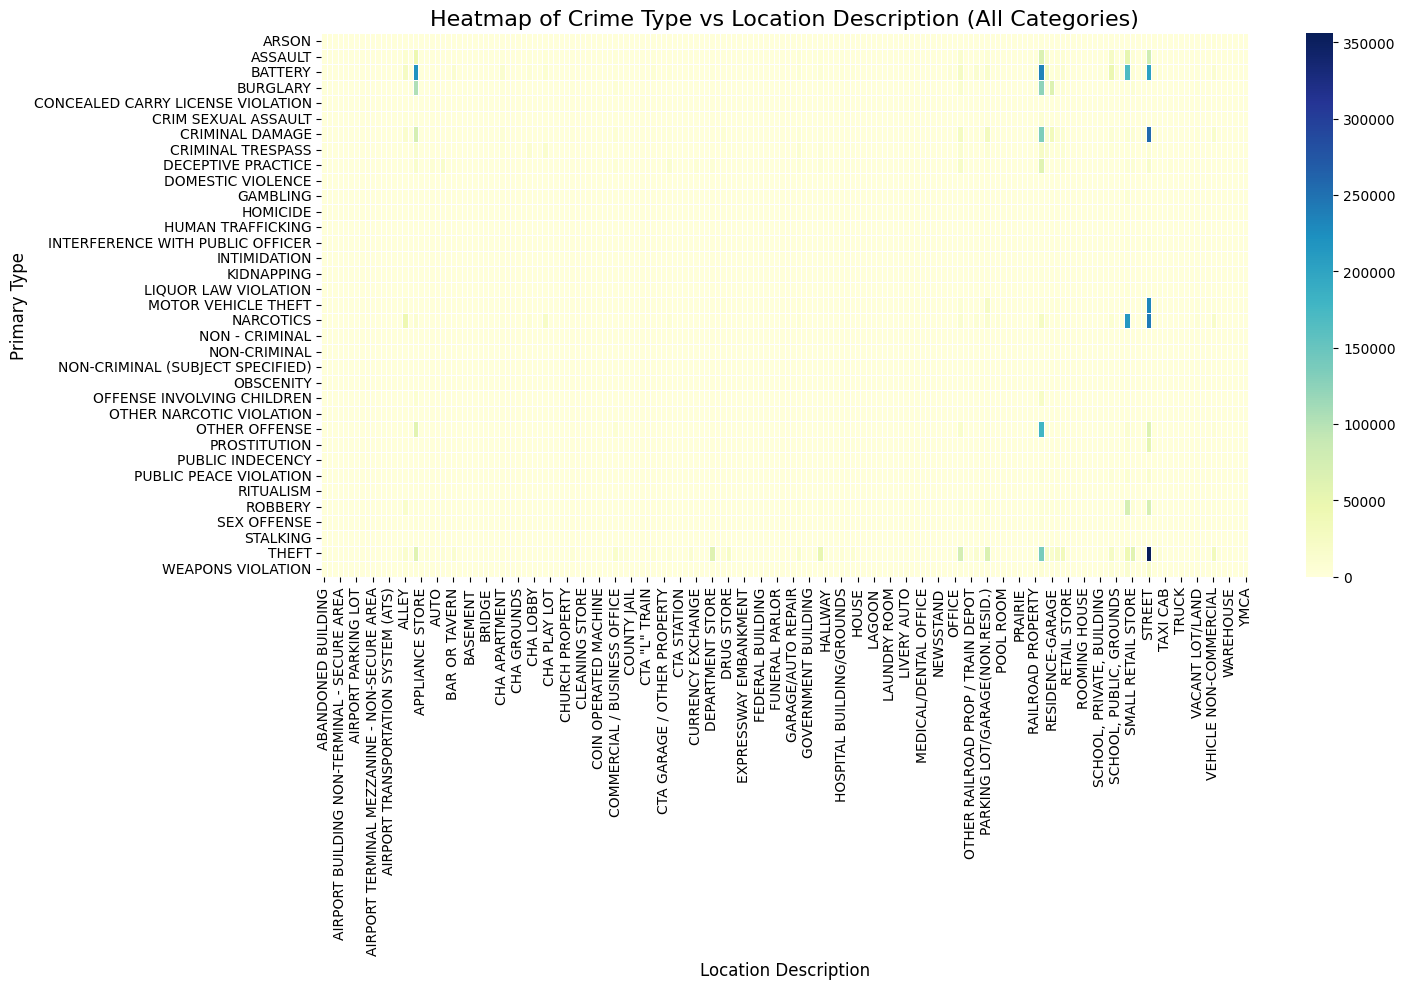

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 결측치 제거
filtered = df_final.dropna(subset=["Primary Type", "Location Description"])

# 교차표 생성
cross_tab = pd.crosstab(filtered["Primary Type"], filtered["Location Description"])

# 히트맵 시각화
plt.figure(figsize=(15, 10))
sns.heatmap(cross_tab, cmap="YlGnBu", linewidths=0.5)

plt.title("Heatmap of Crime Type vs Location Description (All Categories)", fontsize=16)
plt.xlabel("Location Description", fontsize=12)
plt.ylabel("Primary Type", fontsize=12)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

# 결측치 제거
filtered = df_final.dropna(subset=["Primary Type", "Location Description"])

# 교차표 생성 (범죄 유형별 장소 빈도)
crime_location_matrix = pd.crosstab(filtered["Primary Type"], filtered["Location Description"])

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 정규화 (스케일 맞추기)
scaler = StandardScaler()
crime_location_scaled = scaler.fit_transform(crime_location_matrix)

# 클러스터링 (예: 5개 군집)
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(crime_location_scaled)

# 결과를 데이터프레임에 저장
clustered_crimes = pd.DataFrame({
    "Primary Type": crime_location_matrix.index,
    "Cluster": labels
}).sort_values("Cluster")

print(clustered_crimes)


                         Primary Type  Cluster
0                               ARSON        0
4   CONCEALED CARRY LICENSE VIOLATION        0
5                 CRIM SEXUAL ASSAULT        0
14                       INTIMIDATION        0
12                  HUMAN TRAFFICKING        0
13   INTERFERENCE WITH PUBLIC OFFICER        0
10                           GAMBLING        0
9                   DOMESTIC VIOLENCE        0
15                         KIDNAPPING        0
23         OFFENSE INVOLVING CHILDREN        0
21   NON-CRIMINAL (SUBJECT SPECIFIED)        0
22                          OBSCENITY        0
20                       NON-CRIMINAL        0
19                     NON - CRIMINAL        0
17                MOTOR VEHICLE THEFT        0
16               LIQUOR LAW VIOLATION        0
30                            ROBBERY        0
26                       PROSTITUTION        0
27                   PUBLIC INDECENCY        0
28             PUBLIC PEACE VIOLATION        0
31           

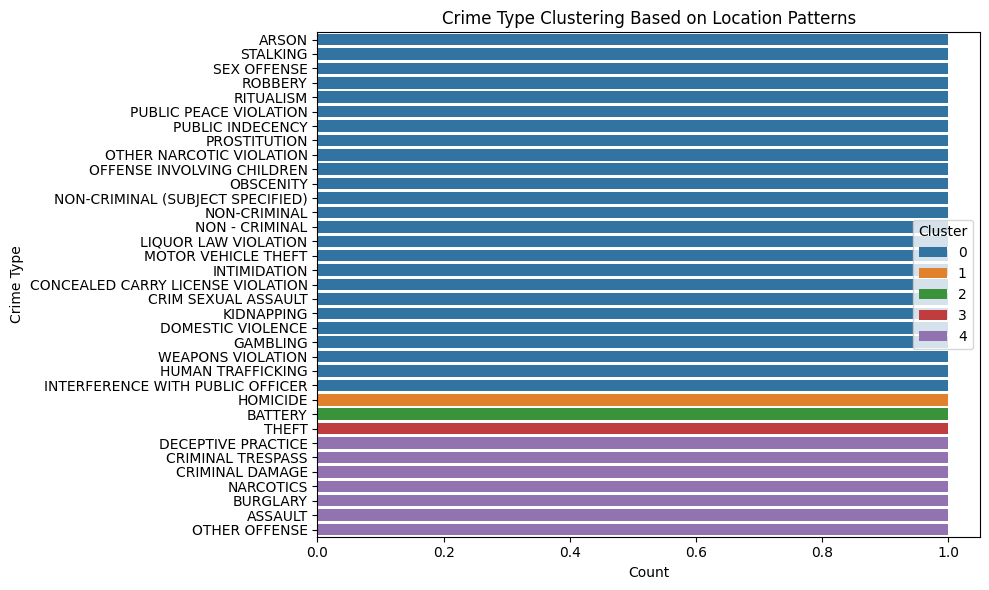

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.countplot(data=clustered_crimes, y="Primary Type", hue="Cluster", palette="tab10")
plt.title("Crime Type Clustering Based on Location Patterns")
plt.xlabel("Count")
plt.ylabel("Crime Type")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


In [ ]:
# 👉 crime_location_matrix 복사해서 클러스터 컬럼 추가
matrix_with_cluster = crime_location_matrix.copy()
matrix_with_cluster['Cluster'] = labels

# 👉 클러스터별로 평균 장소 빈도 계산
cluster_location_mean = matrix_with_cluster.groupby('Cluster').mean()

# 👉 클러스터별 대표 장소 출력
for cluster_num in range(cluster_location_mean.shape[0]):
    print(f"\n🔎 Cluster {cluster_num} - 대표 장소 TOP 5:")
    top_places = cluster_location_mean.loc[cluster_num].sort_values(ascending=False).head(5)
    print(top_places)




🔎 Cluster 0 - 대표 장소 TOP 5:
Location Description
STREET                            16346.96
SIDEWALK                           4739.64
RESIDENCE                          2392.68
PARKING LOT/GARAGE(NON.RESID.)     1335.48
ALLEY                              1316.28
Name: 0, dtype: float64

🔎 Cluster 1 - 대표 장소 TOP 5:
Location Description
STREET       3940.0
AUTO          993.0
APARTMENT     704.0
ALLEY         525.0
HOUSE         473.0
Name: 1, dtype: float64

🔎 Cluster 2 - 대표 장소 TOP 5:
Location Description
RESIDENCE                   235558.0
APARTMENT                   218979.0
STREET                      203055.0
SIDEWALK                    168206.0
SCHOOL, PUBLIC, BUILDING     46507.0
Name: 2, dtype: float64

🔎 Cluster 3 - 대표 장소 TOP 5:
Location Description
STREET                            355850.0
RESIDENCE                         137789.0
OTHER                              74370.0
PARKING LOT/GARAGE(NON.RESID.)     65912.0
DEPARTMENT STORE                   62267.0
Name: 3, dtype: f

## ward

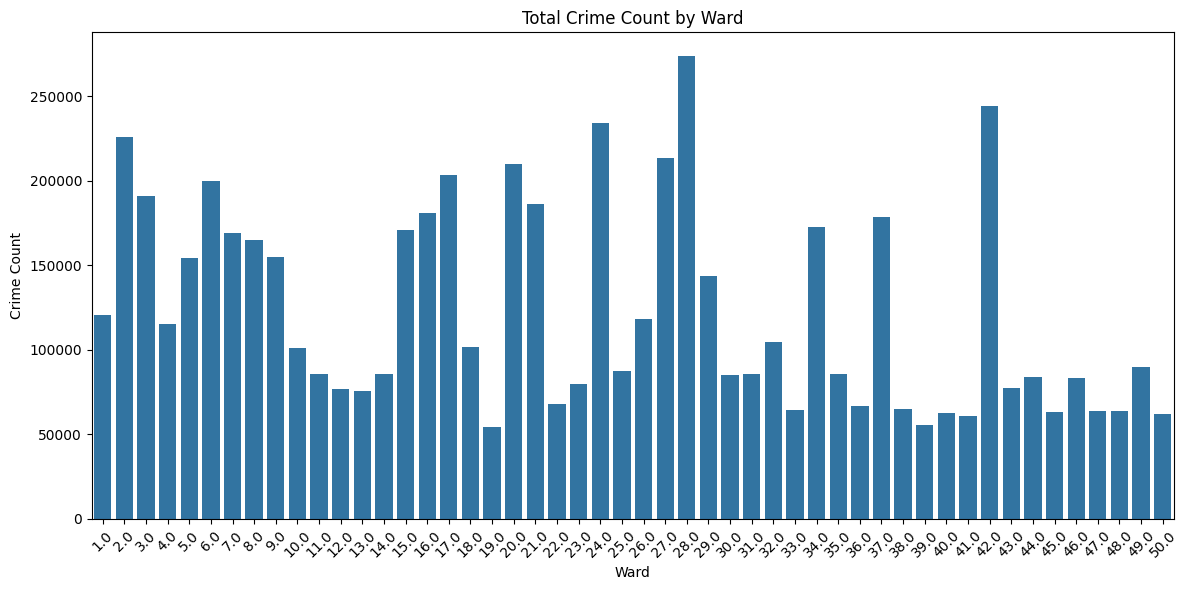

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

ward_crime_counts = df_final['Ward'].value_counts().sort_index()

plt.figure(figsize=(12,6))
sns.barplot(x=ward_crime_counts.index, y=ward_crime_counts.values)
plt.title("Total Crime Count by Ward")
plt.xlabel("Ward")
plt.ylabel("Crime Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


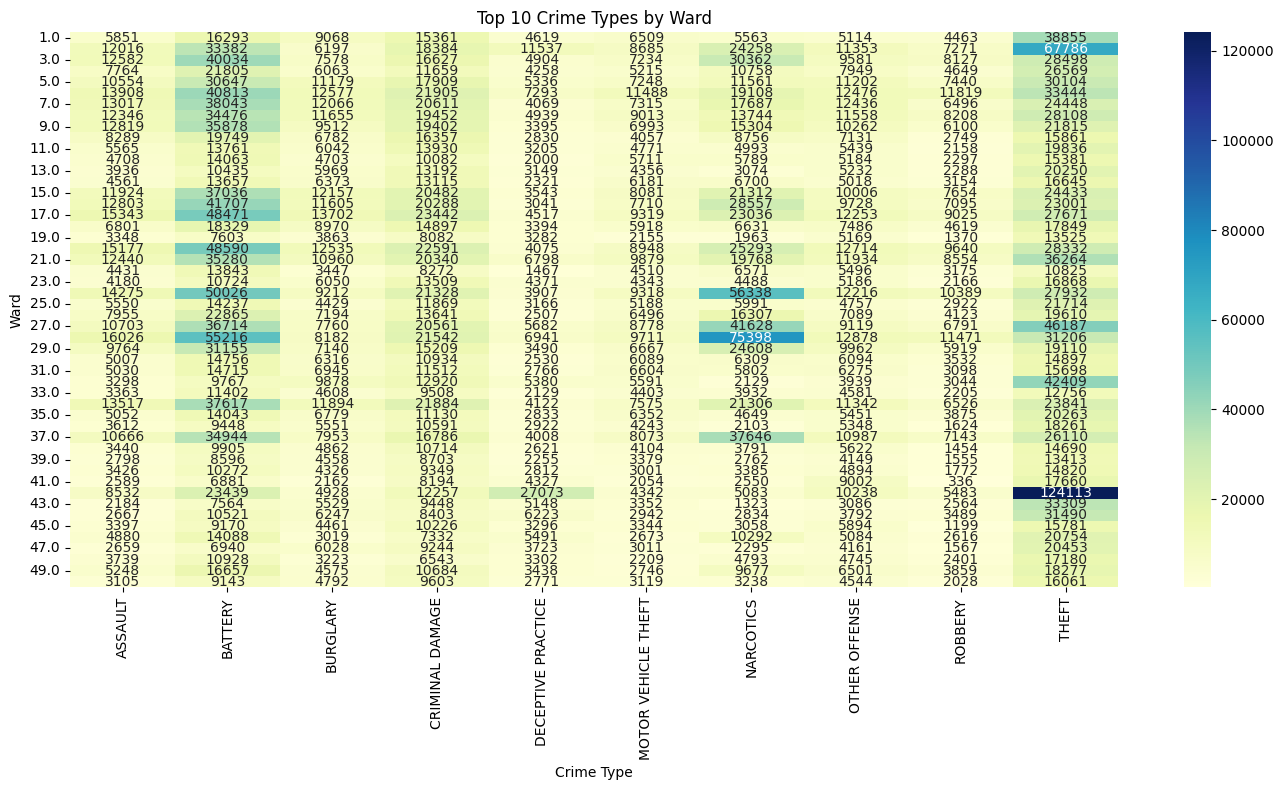

In [ ]:
top10_crimes = df_final['Primary Type'].value_counts().head(10).index
filtered = df_final[df_final['Primary Type'].isin(top10_crimes)]
ward_crime_pivot = pd.crosstab(filtered['Ward'], filtered['Primary Type'])

import seaborn as sns
plt.figure(figsize=(14,8))
sns.heatmap(ward_crime_pivot, annot=True, fmt='d', cmap='YlGnBu')
plt.title("Top 10 Crime Types by Ward")
plt.xlabel("Crime Type")
plt.ylabel("Ward")
plt.tight_layout()
plt.show()


#### ward랑 범죄유형

가설:

귀무가설(H₀): Ward와 범죄 유형은 연관이 없다

대립가설(H₁): Ward에 따라 범죄 유형이 달라진다 (연관 있음)

In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency

# 교차표 생성
contingency_table = pd.crosstab(df_final['Ward'], df_final['Primary Type'])

# 카이제곱 독립성 검정
chi2, p, dof, expected = chi2_contingency(contingency_table)

# 결과 출력
print(f"📊 카이제곱 통계량: {chi2:.2f}")
print(f"📌 p-value: {p:.6f}")
if p < 0.05:
    print("✅ Ward에 따라 범죄 유형에 유의미한 차이가 있습니다 (귀무가설 기각)")
else:
    print("❌ Ward와 범죄 유형은 통계적으로 연관이 없습니다 (귀무가설 채택)")


📊 카이제곱 통계량: 880637.72
📌 p-value: 0.000000
✅ Ward에 따라 범죄 유형에 유의미한 차이가 있습니다 (귀무가설 기각)


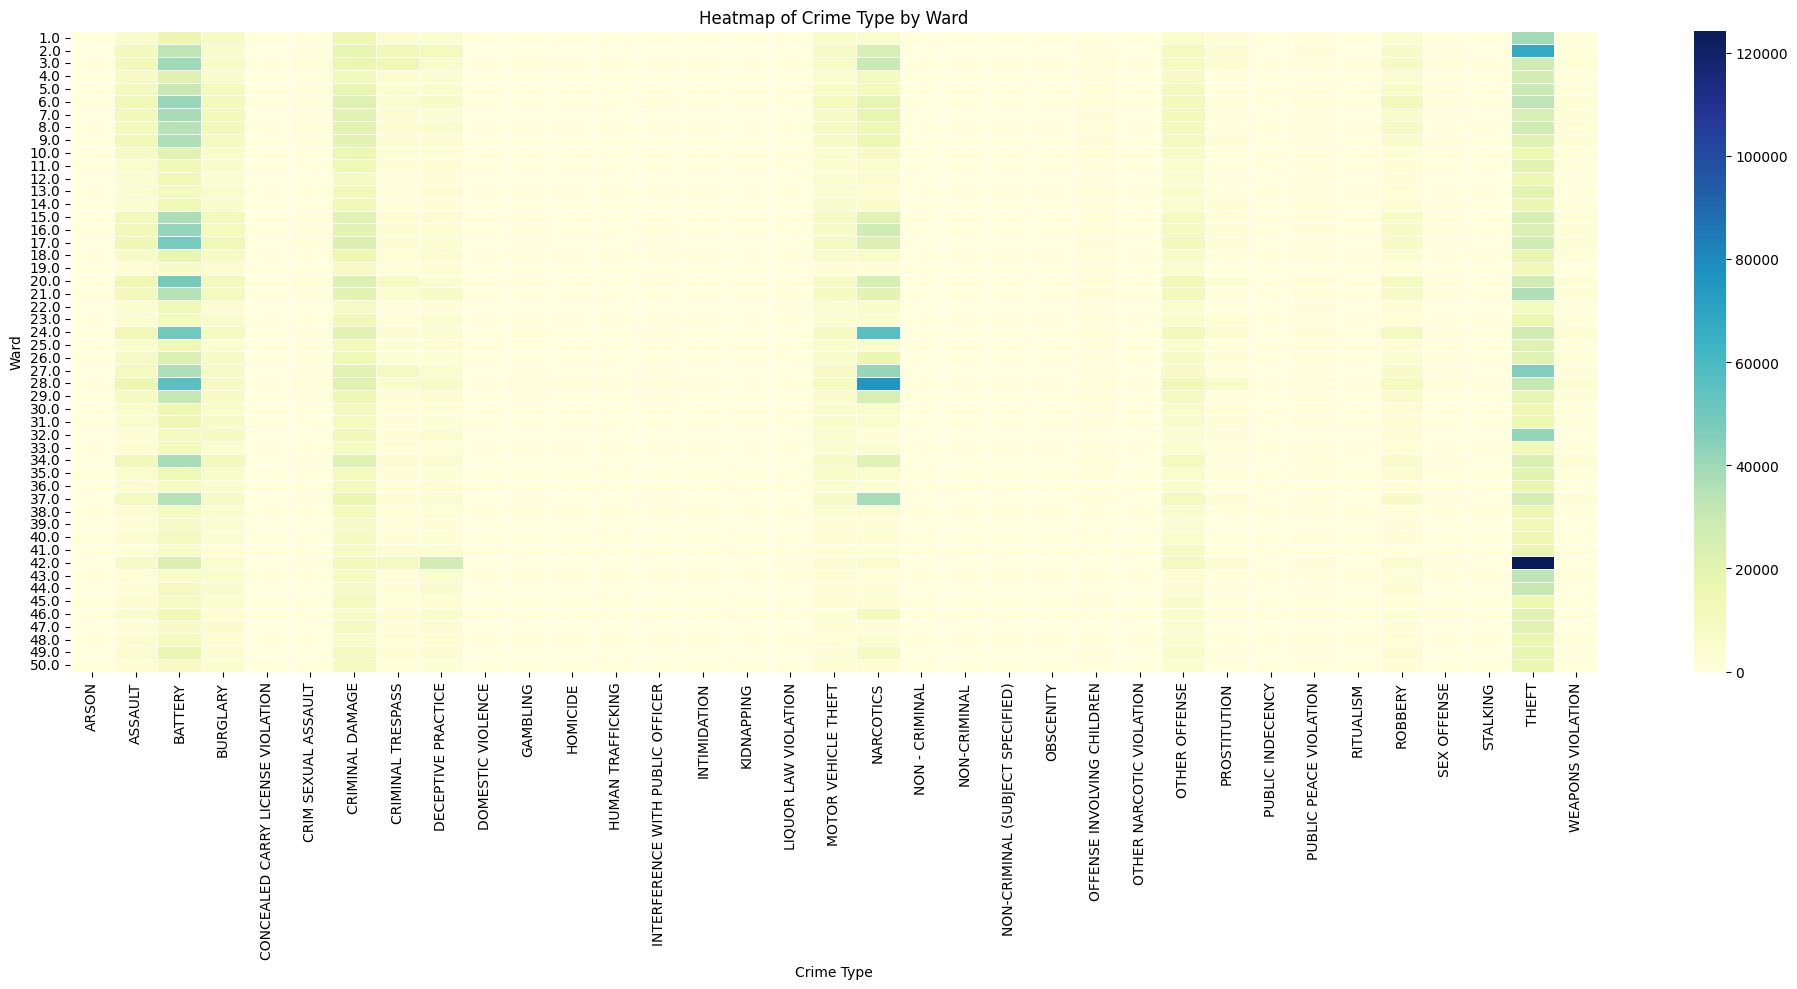

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cross = pd.crosstab(df_final['Ward'], df_final['Primary Type'])

plt.figure(figsize=(20, 10))
sns.heatmap(cross, cmap='YlGnBu', linewidths=0.5)

plt.title('Heatmap of Crime Type by Ward')
plt.xlabel('Crime Type')
plt.ylabel('Ward')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()



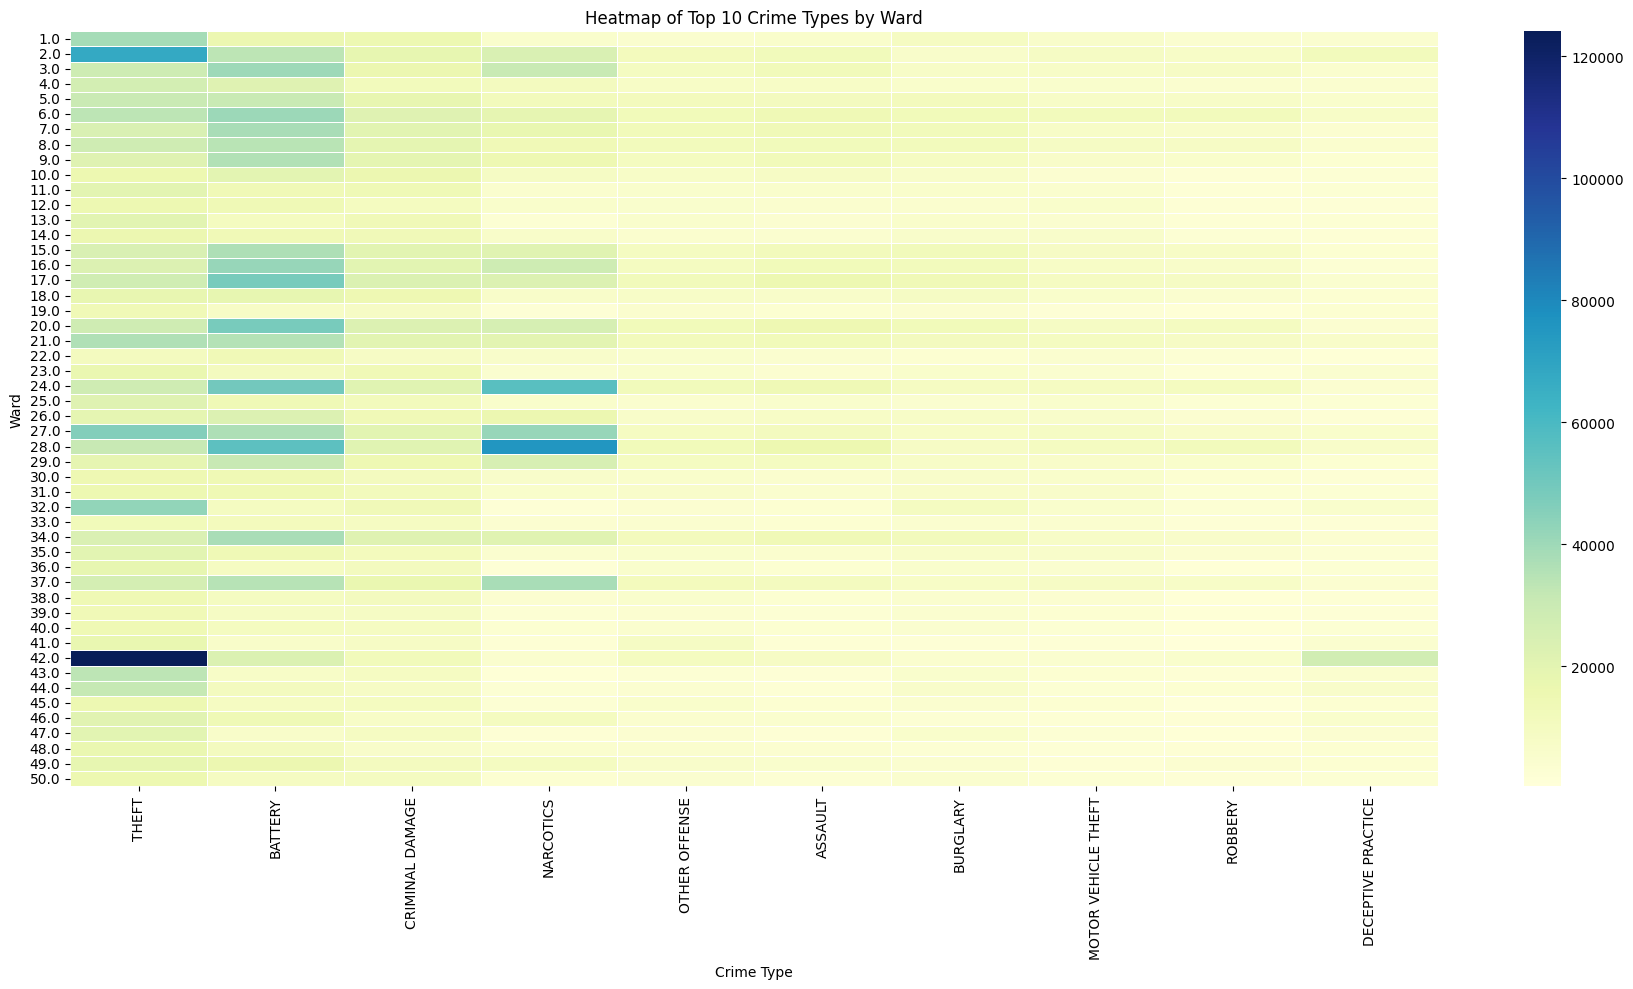

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 범죄 유형 상위 10개 추출
top10_types = df_final['Primary Type'].value_counts().head(10).index

# 2. Ward와 Primary Type 간 교차표 생성 (상위 10개만)
cross_top10 = pd.crosstab(df_final['Ward'], df_final['Primary Type'])
cross_top10 = cross_top10[top10_types]

# 3. 히트맵 시각화 (숫자 표시 추가)
plt.figure(figsize=(18, 10))
sns.heatmap(cross_top10, fmt='d', cmap='YlGnBu', linewidths=0.5)

plt.title('Heatmap of Top 10 Crime Types by Ward')
plt.xlabel('Crime Type')
plt.ylabel('Ward')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [ ]:
!pip install geopandas folium


## 피처 생성

### 신고 위치와 커뮤니티 지역 중심 좌표 사이 거리 계산

In [ ]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from geopy.distance import geodesic

# Community Area 숫자형으로 변환
df_final['Community Area'] = pd.to_numeric(df_final['Community Area'], errors='coerce')

# 시카고 지역 GeoJSON 로딩 + 지역 중심 좌표 계산
geojson_url = "https://data.cityofchicago.org/resource/igwz-8jzy.geojson"
community_gdf = gpd.read_file(geojson_url)
community_gdf['area_numbe'] = pd.to_numeric(community_gdf['area_numbe'])
community_gdf['centroid'] = community_gdf.geometry.centroid
community_gdf['centroid_lat'] = community_gdf.centroid.y
community_gdf['centroid_lon'] = community_gdf.centroid.x
area_centroids = community_gdf[['area_numbe', 'centroid_lat', 'centroid_lon']]
area_centroids.columns = ['Community Area', 'Center_Lat', 'Center_Lon']

# 병합
df_final = df_final.merge(area_centroids, on='Community Area', how='left')

# 거리 계산 함수 정의 및 적용
def calc_distance(row):
    if pd.notnull(row['Latitude']) and pd.notnull(row['Longitude']) and \
       pd.notnull(row['Center_Lat']) and pd.notnull(row['Center_Lon']):
        return geodesic((row['Latitude'], row['Longitude']),
                        (row['Center_Lat'], row['Center_Lon'])).meters
    return None

df_final['Distance_to_Center'] = df_final.apply(calc_distance, axis=1)

# 결과 확인
print(df_final[['Community Area', 'Center_Lat', 'Center_Lon', 'Distance_to_Center']].head())

# 피처 생성 완료된 데이터 저장
df_final.to_csv("/content/features_with_community.csv", index=False)
print("✅ 저장 완료: /content/features_with_community.csv")


<ipython-input-3-5d425f04f9e9>:13: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  community_gdf['centroid'] = community_gdf.geometry.centroid
<ipython-input-3-5d425f04f9e9>:14: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  community_gdf['centroid_lat'] = community_gdf.centroid.y
<ipython-input-3-5d425f04f9e9>:15: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  community_gdf['centroid_lon'] = community_gdf.centroid.x


   Community Area  Center_Lat  Center_Lon  Distance_to_Center
0            46.0   41.741243  -87.551429          540.024156
1            61.0   41.809019  -87.659167         2030.901196
2            22.0   41.922760  -87.699156         1180.419003
3            20.0   41.924348  -87.734740          447.605985
4            49.0   41.706590  -87.623366         1913.286862
✅ 저장 완료: /content/features_with_community.csv


- Community Area : 커뮤니티 지역 코드 (범주형 -> 숫자형)
- Center_Lat : 커뮤니티 지역 중심 위도
- Center_Lan : 커뮤니티 지역 중심 경도
- Distance_t0_Center : 사건 지점과 커뮤니티 지역 중심 간 거리 (m)

**Community Area** (숫자형) : 지역마다 범죄/체포 패턴 다름

**Center_Lat, Center_Lot** (숫자형) : 공간적 위치 자체 의미

**Distance_to_Center** (숫자형) : 중심에서 멀수록 체포 가능성 달라질 수 있음

In [ ]:
import folium

m = folium.Map(location=[41.8781, -87.6298], zoom_start=11)

df_community = pd.read_csv("/content/drive/MyDrive/fianl_pj/features_with_community.csv")
for _, row in df_community.sample(300).dropna(subset=['Latitude', 'Longitude', 'Center_Lat', 'Center_Lon']).iterrows():
    # 신고 위치
    folium.CircleMarker([row['Latitude'], row['Longitude']], radius=3, color='blue').add_to(m)
    # 커뮤니티 지역 중심
    folium.CircleMarker([row['Center_Lat'], row['Center_Lon']], radius=3, color='green').add_to(m)
    # 연결선
    folium.PolyLine([(row['Latitude'], row['Longitude']),
                     (row['Center_Lat'], row['Center_Lon'])], color='green', weight=1).add_to(m)

m.save("/content/community_feature_map.html")
m

### 커뮤니티 지역의 중심위치와 사건 발생 위치 사이의 거리와 체포여부의 상관관계

In [ ]:
df_community = pd.read_csv("/content/drive/MyDrive/fianl_pj/features_with_community.csv")

# NaN 제거 후 정수형 변환
df_community = df_community.dropna(subset=['Arrest', 'Distance_to_Center'])
df_community['Arrest'] = df_community['Arrest'].astype(int)

# 상관계수 계산
correlation = df_community[['Distance_to_Center', 'Arrest']].corr().iloc[0, 1]
print(f"📊 체포 여부와 거리의 상관계수: {correlation:.4f}")

📊 체포 여부와 거리의 상관계수: -0.0011


### 신고 위치와 경찰서 관할 구역의 중심 좌표 사이 거리 계산

In [ ]:
import pandas as pd
import geopandas as gpd
from geopy.distance import geodesic
from shapely.wkt import loads

# 신고 데이터 불러오기
df = pd.read_csv("/content/drive/MyDrive/fianl_pj/crime_data_final_project.csv")
df['District'] = pd.to_numeric(df['District'], errors='coerce')
df['Latitude'] = pd.to_numeric(df['Latitude'], errors='coerce')
df['Longitude'] = pd.to_numeric(df['Longitude'], errors='coerce')

# 경찰 구역 데이터 불러오기 (CSV 파일)
district_df = pd.read_csv("/content/drive/MyDrive/fianl_pj/PoliceDistrictDec2012_20250327.csv")

# the_geom 열을 geometry로 변환
# 문자열로 된 WKT 데이터를 shapely 객체로 변환
district_df['geometry'] = district_df['the_geom'].apply(loads)

# Pandas DataFrame을 GeoDataFrame으로 변환
district_gdf = gpd.GeoDataFrame(district_df, geometry='geometry')

# 중심 좌표 계산
district_gdf['district_num'] = pd.to_numeric(district_gdf['DIST_NUM'], errors='coerce')
district_gdf['centroid'] = district_gdf.geometry.centroid
district_gdf['centroid_lat'] = district_gdf.centroid.y
district_gdf['centroid_lon'] = district_gdf.centroid.x

district_centroids = district_gdf[['district_num', 'centroid_lat', 'centroid_lon']]
district_centroids.columns = ['District', 'Police_Lat', 'Police_Lon']

# 병합 (신고 데이터 + 경찰서 중심)
df = df.merge(district_centroids, on='District', how='left')

# 거리 계산 함수
def calc_distance_to_police(row):
    if pd.notnull(row['Latitude']) and pd.notnull(row['Longitude']) and \
       pd.notnull(row['Police_Lat']) and pd.notnull(row['Police_Lon']):
        return geodesic((row['Latitude'], row['Longitude']),
                        (row['Police_Lat'], row['Police_Lon'])).meters
    return None

df['Distance_to_Police'] = df.apply(calc_distance_to_police, axis=1)

# 결과 저장
df.to_csv("/content/features_with_police_distance.csv", index=False)
print("✅ 저장 완료: features_with_police_distance.csv")

# 확인
print(df[['District', 'Latitude', 'Longitude', 'Police_Lat', 'Police_Lon', 'Distance_to_Police']].head())

✅ 저장 완료: features_with_police_distance.csv
   District   Latitude  Longitude  Police_Lat  Police_Lon  Distance_to_Police
0       4.0  41.745793 -87.549140   41.701782  -87.560734         4982.425449
1       9.0  41.817229 -87.637328   41.819765  -87.665038         2319.442313
2      14.0  41.927052 -87.712174   41.918702  -87.692326         1889.708414
3      25.0  41.925325 -87.739975   41.921671  -87.760009         1710.610184
4      22.0  41.691785 -87.635116   41.704723  -87.672382         3418.757593


- District : 경찰 구역 번호
- Police_Lat : 경찰 구역 중심 위도
- Police_Lan : 커뮤니티 지역 중심 경도
- Distance_t0_Police : 사건 지점과 경찰 구역 중심 간 거리 (m)

In [ ]:
df_police = pd.read_csv("/content/features_with_police_distance.csv")

In [ ]:
import folium

m = folium.Map(location=[41.8781, -87.6298], zoom_start=11)


df_police = pd.read_csv("/content/features_with_police_distance.csv")
for _, row in df_police.sample(300).dropna(subset=['Latitude', 'Longitude', 'Police_Lat', 'Police_Lon']).iterrows():
    # 신고 위치
    folium.CircleMarker([row['Latitude'], row['Longitude']], radius=3, color='blue').add_to(m)
    # 경찰서 위치
    folium.CircleMarker([row['Police_Lat'], row['Police_Lon']], radius=3, color='red').add_to(m)
    # 연결선
    folium.PolyLine([(row['Latitude'], row['Longitude']),
                     (row['Police_Lat'], row['Police_Lon'])], color='green', weight=1).add_to(m)

m.save("/content/police_distance_map.html")
m

### 경찰 관할 구역의 중심위치와 사건 발생 위치 사이의 거리와 체포여부의 상관관계

In [ ]:
df_police = df_police.dropna(subset=['Arrest', 'Distance_to_Police'])
df_police['Arrest'] = df_police['Arrest'].astype(int)
correlation = df_police[['Distance_to_Police', 'Arrest']].corr().iloc[0, 1]
print(f"📊 체포 여부와 거리의 상관계수: {correlation:.4f}")


📊 체포 여부와 거리의 상관계수: -0.0441


<ipython-input-5-049833ecc6b3>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_police['Arrest'] = df_police['Arrest'].astype(int)


### 경찰 관할 구역과의 거리와 범죄 건수의 상관 관계

In [ ]:
# 거리 결측치 제거
df_police = df_police.dropna(subset=['Distance_to_Police'])

# 거리 구간 나누기
df_police['Distance_Bin'] = pd.cut(df_police['Distance_to_Police'], bins=range(0, 6000, 500))

# 거리 구간별 범죄 건수 집계
grouped = df_police.groupby('Distance_Bin').size().reset_index(name='Crime Count')

# 각 구간의 중심값 계산 (구간 → 수치화)
grouped['Bin_Center'] = grouped['Distance_Bin'].apply(lambda x: x.mid)

# 상관계수 계산
correlation = grouped[['Bin_Center', 'Crime Count']].corr().iloc[0, 1]
print(f"📊 경찰 관할 중심 거리와 범죄 발생 건수의 상관계수: {correlation:.4f}")


📊 경찰 관할 중심 거리와 범죄 발생 건수의 상관계수: -0.6259


<ipython-input-6-afea1977caec>:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_police.groupby('Distance_Bin').size().reset_index(name='Crime Count')


In [ ]:
print(grouped[['Distance_Bin', 'Crime Count']])

    Distance_Bin  Crime Count
0       (0, 500]       249962
1    (500, 1000]       728960
2   (1000, 1500]      1127560
3   (1500, 2000]      1273994
4   (2000, 2500]      1035186
5   (2500, 3000]       657282
6   (3000, 3500]       373158
7   (3500, 4000]       228640
8   (4000, 4500]       122033
9   (4500, 5000]        81574
10  (5000, 5500]        66678


📍 경찰 관할 구역과의 거리와 범죄 건수는 음의 상관 관계 -> 거리가 멀수록 범죄가 더 적게 발생

1. 경찰서 = 범죄가 많이 발생하는 지역에 위치함

- 시카고 같은 도시에서는 범죄가 자주 발생하는 지역에 경찰서를 의도적으로 배치

- 즉, 경찰서 위치는 원인이 아니라 결과임 : 범죄가 많아서 경찰서가 있는 것. 경찰서가 있어서 범죄가 줄어든다는 보장은 없음

2. 유동 인구가 많고 중심지라서
- 경찰서 주변은 상업지구, 교통 중심지, 번화가일 가능성 높음

- 이런 지역은 사람도 많고 사건도 많음

In [ ]:
import statsmodels.api as sm
import pandas as pd



# 결측치 제거
df_clean = df_police.dropna(subset=["Distance_to_Police"])

# '범죄 건수'가 따로 없다면, 각 행이 1건이라고 보고 y = 1로 설정
df_clean["Crime_Count"] = 1

# 회귀 모델 준비
X = sm.add_constant(df_clean["Distance_to_Police"])  # 독립 변수
y = df_clean["Crime_Count"]                          # 종속 변수

# 모델 적합
model = sm.OLS(y, X).fit()

# 결과 출력
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:            Crime_Count   R-squared:                        -inf
Model:                            OLS   Adj. R-squared:                   -inf
Method:                 Least Squares   F-statistic:                -6.170e+06
Date:                Wed, 02 Apr 2025   Prob (F-statistic):               1.00
Time:                        08:40:53   Log-Likelihood:             2.0509e+08
No. Observations:             6170296   AIC:                        -4.102e+08
Df Residuals:                 6170294   BIC:                        -4.102e+08
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  1.0000   6.87

/usr/local/lib/python3.11/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


## 피처링

### Primary Type - One-hot encoding




In [ ]:
import pandas as pd

# 예시: Primary Type 컬럼만 추출하여 원핫 인코딩
df_onehot = pd.get_dummies(df_final['Primary Type'],dtype=int)

# 결과 확인
print(df_onehot.head())


   ARSON  ASSAULT  BATTERY  BURGLARY  CONCEALED CARRY LICENSE VIOLATION  \
0      0        0        0         0                                  0   
1      0        0        0         0                                  0   
2      0        0        0         0                                  0   
3      0        0        0         0                                  0   
4      0        0        0         0                                  0   

   CRIM SEXUAL ASSAULT  CRIMINAL DAMAGE  CRIMINAL TRESPASS  \
0                    0                0                  0   
1                    0                0                  0   
2                    0                0                  0   
3                    0                0                  0   
4                    0                0                  0   

   DECEPTIVE PRACTICE  DOMESTIC VIOLENCE  ...  OTHER OFFENSE  PROSTITUTION  \
0                   0                  0  ...              0             0   
1                   

### Location  Description -  Target Mean Encoding

각 장소별 평균 체포율 -> 체포 여부 예측

In [ ]:
# 장소별 체포율 평균 계산
location_mean_arrest = df_final.groupby('Location Description')['Arrest'].mean()

# 매핑
df_final['Loc_Arrest_Mean'] = df_final['Location Description'].map(location_mean_arrest)

# 상위 5개 행 확인
print(df_final[['Location Description', 'Arrest', 'Loc_Arrest_Mean']].head())



  Location Description  Arrest  Loc_Arrest_Mean
0            RESIDENCE   False         0.142246
1            RESIDENCE   False         0.142246
2            RESIDENCE   False         0.142246
3                OTHER   False         0.195080
4            RESIDENCE   False         0.142246


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, classification_report

# 1. 결측치 제거 (Loc_Arrest_Mean, Arrest)
df_ml = df_final.dropna(subset=['Loc_Arrest_Mean', 'Arrest'])

# 2. 피처(X), 타겟(y) 정의
X = df_ml[['Loc_Arrest_Mean']]  # 장소 기반 체포율 피처
y = df_ml['Arrest'].astype(int)  # True/False → 1/0

# 3. 데이터 나누기
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. 모델 학습
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# 5. 예측 및 평가
y_pred = model.predict(X_test)

# 6. 평가 결과 출력
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
print(f"✅ 정확도 (Accuracy): {accuracy:.4f}")
print(f"✅ 재현율 (Recall): {recall:.4f}")
print(classification_report(y_test, y_pred))


✅ 정확도 (Accuracy): 0.7331
✅ 재현율 (Recall): 0.2989
              precision    recall  f1-score   support

           0       0.77      0.90      0.83    884493
           1       0.55      0.30      0.39    349521

    accuracy                           0.73   1234014
   macro avg       0.66      0.60      0.61   1234014
weighted avg       0.71      0.73      0.70   1234014



### Location Description - label encoding

각 장소마다 가장 자주 발생하는 범죄 유형

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# 1. 상위 10개 범죄 유형 추출
top10_types = df_final['Primary Type'].value_counts().head(10).index

# 2. 범죄 유형이 상위 10개에 해당하지 않으면 OTHER로 변환
df_final['Primary Type (Top10)'] = df_final['Primary Type'].apply(
    lambda x: x if x in top10_types else 'OTHER'
)

# 3. 장소별 가장 흔한 상위 10개 범죄 유형 계산
top_location_crimes = df_final.groupby('Location Description')['Primary Type (Top10)'] \
    .agg(lambda x: x.value_counts().index[0]) \
    .reset_index()
top_location_crimes.columns = ['Location Description', 'Top_Crime_Type_Top10']

# 4. Location Description에 따라 새로운 피처 생성
df_final['Top_Location_Crime_Top10'] = df_final['Location Description'].map(
    dict(zip(top_location_crimes['Location Description'], top_location_crimes['Top_Crime_Type_Top10']))
)

# 5. 숫자로 인코딩
le = LabelEncoder()
df_final['Top_Location_Crime_Top10_Label'] = le.fit_transform(df_final['Top_Location_Crime_Top10'])

# 6. 결과 확인
print(df_final[['Location Description', 'Top_Location_Crime_Top10', 'Top_Location_Crime_Top10_Label']].head())




  Location Description Top_Location_Crime_Top10  \
0            RESIDENCE                  BATTERY   
1            RESIDENCE                  BATTERY   
2            RESIDENCE                  BATTERY   
3                OTHER                    THEFT   
4            RESIDENCE                  BATTERY   

   Top_Location_Crime_Top10_Label  
0                               0  
1                               0  
2                               0  
3                               8  
4                               0  


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, recall_score

# 1. 상위 10개 범죄 유형 선택
top10_types = df_final['Primary Type'].value_counts().head(10).index
df_ml = df_final[df_final['Top_Location_Crime_Top10'].notna()].copy()
df_ml['Primary Type (Top10)'] = df_ml['Primary Type'].apply(lambda x: x if x in top10_types else 'OTHER')

# 2. 타겟 인코딩 (Top10만 포함)
df_ml = df_ml[df_ml['Primary Type (Top10)'] != 'OTHER']
y = LabelEncoder().fit_transform(df_ml['Primary Type (Top10)'])

# 3. 피처 인코딩 (Top_Location_Crime_Top10_Label 사용)
X = df_ml[['Top_Location_Crime_Top10_Label']].values  # 2D 배열

# 4. 학습/테스트 분리
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. 모델 학습
model = RandomForestClassifier(random_state=42)
model.fit(x_train, y_train)

# 6. 예측 및 평가
y_pred = model.predict(x_test)
acc = accuracy_score(y_test, y_pred)
recall_macro = recall_score(y_test, y_pred, average='macro')

# 7. 결과 출력
print(f"📊 정확도 (Accuracy): {acc:.4f}")
print(f"🔁 평균 재현율 (Recall - macro): {recall_macro:.4f}")
print("📄 상세 분류 리포트:\n")
print(classification_report(y_test, y_pred))




📊 정확도 (Accuracy): 0.3369
🔁 평균 재현율 (Recall - macro): 0.2064
📄 상세 분류 리포트:



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00     75406
           1       0.31      0.51      0.38    225384
           2       0.51      0.18      0.26     71693
           3       0.34      0.01      0.02    141947
           4       0.56      0.20      0.30     44797
           5       0.00      0.00      0.00     58253
           6       0.37      0.44      0.40    135041
           7       0.60      0.01      0.01     76408
           8       0.33      0.01      0.01     46532
           9       0.33      0.72      0.45    257002

    accuracy                           0.34   1132463
   macro avg       0.34      0.21      0.18   1132463
weighted avg       0.33      0.34      0.26   1132463



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### ward

범죄 발생 건수 기반 피처

In [ ]:
ward_crime_count = df_final.groupby('Ward').size()
df_final['Ward_Crime_Count'] = df_final['Ward'].map(ward_crime_count)


ward 별 체포율 기반 피처

In [ ]:
ward_arrest_rate = df_final.groupby('Ward')['Arrest'].mean()
df_final['Ward_Arrest_Rate'] = df_final['Ward'].map(ward_arrest_rate)


ward 별 주요 범죄 유형 ( 대표범죄 )

In [ ]:
top_crime_by_ward = df_final.groupby('Ward')['Primary Type'].agg(lambda x: x.value_counts().index[0])
df_final['Ward_Top_Crime'] = df_final['Ward'].map(top_crime_by_ward)


# XGBoost

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker


# 데이터 불러오기

df = pd.read_csv('/content/drive/MyDrive/fianl_pj/final_crime_data.csv')

type_counts = df['Primary Type'].value_counts()
valid_types = type_counts[type_counts > 100].index
df = df[df['Primary Type'].isin(valid_types)]


In [ ]:
# 사용할 피처
features = [
    'Domestic', 'Community Area', 'Per Capita Income',
    'District', 'Ward', 'Location Description', 'Beat',
    'Arrest', 'Year', 'Month', 'Day', 'Hour', 'Percent of labor force'
]

df = df.dropna(subset=features + ['Primary Type'])

# 인코딩

df['Domestic'] = df['Domestic'].astype(int)
df['Arrest'] = df['Arrest'].astype(int)

# 범주형 숫자형 → Label Encoding
label_cols = ['District', 'Ward', 'Beat']
for col in label_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

# 문자열 → Frequency Encoding
freq_encoding = df['Location Description'].value_counts().to_dict()
df['Location_Desc_Freq'] = df['Location Description'].map(freq_encoding)
df.drop(columns=['Location Description'], inplace=True)

# 불필요한 object 컬럼 제거
df = df.drop(columns=[
    'Unnamed: 0', 'ID', 'Case Number', 'Date', 'Block', 'IUCR',
    'Description', 'FBI Code', 'Updated On', 'Location'
], errors='ignore')

# Primary Type → 타겟 인코딩

le_target = LabelEncoder()
df['Primary Type'] = le_target.fit_transform(df['Primary Type'])

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb
import time

# 샘플 추출 (30%)
df_sample = df.sample(frac=0.3, random_state=42)
X_sample = df_sample.drop(columns=['Primary Type'])
y_sample = df_sample['Primary Type']

# XGBoost 기본 모델
xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(le_target.classes_),
    tree_method='hist'
)

# 튜닝할 파라미터 범위 (속도 중심)
param_dist = {
    'max_depth': [5, 7],
    'learning_rate': [0.01, 0.03],
    'n_estimators': [100,200,300],
    'subsample': [0.7, 0.9],
    'colsample_bytree': [0.7, 0.8, 1.0]
}


# 빠른 튜닝용 RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=8,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# 튜닝 시작
start = time.time()
random_search.fit(X_sample, y_sample)
print("✅ 튜닝 완료! 소요 시간:", round(time.time() - start, 2), "초")
print("✅ Best Parameters (샘플 기반):", random_search.best_params_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


✅ 튜닝 완료! 소요 시간: 24045.78 초
✅ Best Parameters (샘플 기반): {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.01, 'colsample_bytree': 0.7}


In [ ]:
# 전체 데이터셋 준비 (그대로 OK)
X_full = df.drop(columns=['Primary Type'])
y_full = df['Primary Type']

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, stratify=y_full, random_state=42
)

# 최적 파라미터로 전체 학습
best_model = xgb.XGBClassifier(
    **random_search.best_params_,
    objective='multi:softmax',
    num_class=len(le_target.classes_),
    tree_method='hist',
    eval_metric='mlogloss',
    verbosity=1
)

# 소요 시간 측정 시작
start_time = time.time()

# 모델 학습
best_model.fit(X_train, y_train)

# 평가
y_pred = best_model.predict(X_test)
print("\n📊 정확도:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le_target.classes_))


NameError: name 'df' is not defined